In [1]:
# Imports and settings

import os
import matplotlib.pyplot as plt
import pandas as pd

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE" # Before importing h5flow

import numpy as np
import h5flow

In [2]:
# DUNE plot style
import sys, os; sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "..", "utils"))
from dune_plot import apply_dune_style, dune_label
apply_dune_style()

In [3]:
max_files = 1000

In [4]:
def thd_correct(array):
    segment_size = 25
    n_ticks = array.shape[-1]
    n_segments = n_ticks // segment_size

    # reshape instead of advanced indexing
    trimmed = array[..., :n_segments*segment_size]
    segments = trimmed.reshape(*array.shape[:-1], n_segments, segment_size)

    ranges = np.ptp(segments, axis=-1)
    means = np.mean(segments, axis=-1)

    mask_zero = ranges != 0
    ranges = np.where(mask_zero, ranges, np.nan)
    means = np.where(mask_zero, means, np.nan)

    ordering = np.argsort(ranges, axis=-1)
    sorted_means = np.take_along_axis(means, ordering, axis=-1)
    average_mean = np.mean(sorted_means[..., 1:3], axis=-1)
    filtered_wvfm = array - average_mean[..., None]

    return filtered_wvfm

In [5]:
def find_valid_triggers(samples):
    pmt_wvfm_v2 = samples[:, :]*(-0.25) # The PMT pulse has negative polarity

    noise_sum_all = np.sum(pmt_wvfm_v2[:,5:100], axis=-1) # These are sums over empty noise, not a necessary step
    noise_sum_fast = np.sum(pmt_wvfm_v2[:,5:18], axis=-1) # These are sums over empty noise, not a necessary step

    fast_light = np.sum(pmt_wvfm_v2[:,105:118], axis=-1) - noise_sum_fast # the PMT waveform is always at the same position
    all_light = np.sum(pmt_wvfm_v2[:,105:200], axis=-1) - noise_sum_all
    ratio = fast_light / all_light

    fprompt_mask = (ratio > 0.001) & (ratio < 0.2)
    thd_mask = (pmt_wvfm_v2[:,100:300] > 70) # require that the waveform have some width (there are these weird gaussians)
    pick_out_low = (np.sum(thd_mask[:,5:120], axis=-1) <= 15) # Require that it not just be PMT crosstalk or noise
    
    valid_trig = fprompt_mask & (~pick_out_low) # Combine the masks
    return valid_trig

In [6]:
def extract_time(x):

    if "no_source" in x:
        return -1
    return int(x.split("/")[-2][9:12].replace("u", "").replace("r_", ""))


In [7]:
base_folder = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/"
background_folder = [os.path.join(base_folder,f) for f in os.listdir(base_folder) if "no_source" in f]
source_folder = [os.path.join(base_folder,f) for f in os.listdir(base_folder) if ("no_source" not in f and "timer" not in f)]

In [8]:
background_files = []
for folder in background_folder:
    num_files = 0
    for file in os.listdir(folder):
        num_files += 1
        if file.endswith(".hdf5"):
            background_files.append(os.path.join(folder, file))
        else:
            continue

source_files = []
for folder in source_folder:
    num_files = 0
    for file in os.listdir(folder):
        num_files += 1
        if file.endswith(".hdf5"):
            source_files.append(os.path.join(folder,file))
        else:
            continue

In [9]:
path = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/two_trig_195us_period/mpd_run_run2data_rctl_641_p80_v0p2.FLOW.hdf5"
file = h5flow.data.H5FlowDataManager(path, "r")
file['light/wvfm/', '/light/events/', '/light/sum_hits/']['det']

masked_array(
  data=[[[--, --, --, ..., --, --, --]],

        [[--, --, --, ..., --, --, --]],

        [[--, --, --, ..., --, --, --]],

        ...,

        [[--, --, --, ..., --, --, --]],

        [[--, --, --, ..., --, --, --]],

        [[--, --, --, ..., --, --, --]]],
  mask=[[[ True,  True,  True, ...,  True,  True,  True]],

        [[ True,  True,  True, ...,  True,  True,  True]],

        [[ True,  True,  True, ...,  True,  True,  True]],

        ...,

        [[ True,  True,  True, ...,  True,  True,  True]],

        [[ True,  True,  True, ...,  True,  True,  True]],

        [[ True,  True,  True, ...,  True,  True,  True]]],
  fill_value=63,
  dtype=uint8)

In [10]:
records = []
for path in background_files[0:max_files]:
    file = h5flow.data.H5FlowDataManager(path, mode="r")
    print(f"Processing file: {path}")
    pmt_waveforms = file['/light/sum_tpc_hits/', '/light/events/', '/light/wvfm/']["samples"][:, 0, 0, 0, 16, :500] # This is the PMT waveform, ADC 0 chan 16
    samples = thd_correct(pmt_waveforms)
    valid_triggers = find_valid_triggers(samples)
    valid_events = np.where(valid_triggers==1)[0] # First readout window

    event_id = np.ma.filled(file['light/wvfm/', '/light/events/', '/light/sum_hits/']['id'])[:,0,0]
    fprompts = np.ma.filled(file['light/wvfm/', '/light/events/', '/light/sum_hits/']['fprompt'], np.nan)[:,0,0]
    tpc = np.ma.filled(file['light/wvfm/', '/light/events/', '/light/sum_hits/']['tpc'], 100)[:,0,0]
    det = np.ma.filled(file['light/wvfm/', '/light/events/', '/light/sum_hits/']['det'], 64)[:,0,0]
    tpc_sum = np.ma.filled(file['light/wvfm/', '/light/events/', '/light/sum_hits/']['integral'], np.nan)[:,0,0]
    
    records.extend(
        {
            "file": path,
            "event_id": event_id[i],
            "delay": extract_time(path),
            "fprompt": fprompts[i],
            "tpc": tpc[i],
            "det": det[i],
            "energy": tpc_sum[i],
            "R": "R1",
            "valid_event": i
        }
        for i in valid_events
    )

for path in source_files[0:max_files]:
    file = h5flow.data.H5FlowDataManager(path, mode="r")
    print(f"Processing file: {path}")
    pmt_waveforms = file['/light/sum_tpc_hits/', '/light/events/', '/light/wvfm/']["samples"][:, 0, 0, 0, 16, :500] # This is the PMT waveform, ADC 0 chan 16
    samples = thd_correct(pmt_waveforms)
    valid_triggers = find_valid_triggers(samples)
    valid_events = np.where(valid_triggers==1)[0] # First readout window
    next_valid = valid_events + 1 # Second readout window

    event_id = np.ma.filled(file['light/wvfm/', '/light/events/', '/light/sum_hits/']['id'])[:,0,0]
    fprompts = np.ma.filled(file['light/wvfm/', '/light/events/', '/light/sum_hits/']['fprompt'], np.nan)[:,0,0]
    tpc = np.ma.filled(file['light/wvfm/', '/light/events/', '/light/sum_hits/']['tpc'], 100)[:,0,0]
    det = np.ma.filled(file['light/wvfm/', '/light/events/', '/light/sum_hits/']['det'], 64)[:,0,0]
    tpc_sum = np.ma.filled(file['light/wvfm/', '/light/events/', '/light/sum_hits/']['integral'], np.nan)[:,0,0]
    
    records.extend(
        {
            "file": path,
            "event_id": event_id[i],
            "delay": extract_time(path),
            "fprompt": fprompts[i],
            "tpc": tpc[i],
            "det": det[i],
            "energy": tpc_sum[i],
            "R": "R1",
            "valid_event": i
        }
        for i in valid_events
    )
    records.extend(
        {
            "file": path,
            "event_id": event_id[i],
            "delay": extract_time(path),
            "fprompt": fprompts[i],
            "tpc": tpc[i],
            "det": det[i],
            "energy": tpc_sum[i],
            "R": "R2",
            "valid_event": i
        }
        for i in next_valid
    )

Processing file: /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p11_v0p2.FLOW.hdf5
Processing file: /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p44_v0p2.FLOW.hdf5
Processing file: /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p67_v0p2.FLOW.hdf5
Processing file: /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p6_v0p2.FLOW.hdf5
Processing file: /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p8_v0p2.FLOW.hdf5
Processing file: /pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/mpd_run_run2data_rctl_639_p39_v0p2.FLOW.hdf5
Proces

In [ ]:
# Read csv instead of processing files
records_dict = {}
for i, item in enumerate(records):
    records_dict[i] = item

records_df = pd.DataFrame.from_dict(records_dict, orient="index")
records_df.to_csv("processed_AmBe_data_sum_hits.csv", index=False)


In [10]:
records = pd.read_csv("processed_AmBe_data_sum_hits.csv").to_dict(orient="records")

In [11]:

df = pd.DataFrame(records)
# replace delay = 960 with delay = 80
df["delay"] = df["delay"].replace(960, 80)

In [12]:
df.delay.unique()

array([ -1, 272,  51, 195, 109,  32, 224,  80, 243, 147, 291, 320, 128,
       176])

In [13]:
# save the dataframe
df.to_csv("processed_AmBe_data_sum_hits.csv", index=False)

In [14]:
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
bins = np.arange(0, 1.1, 0.02)

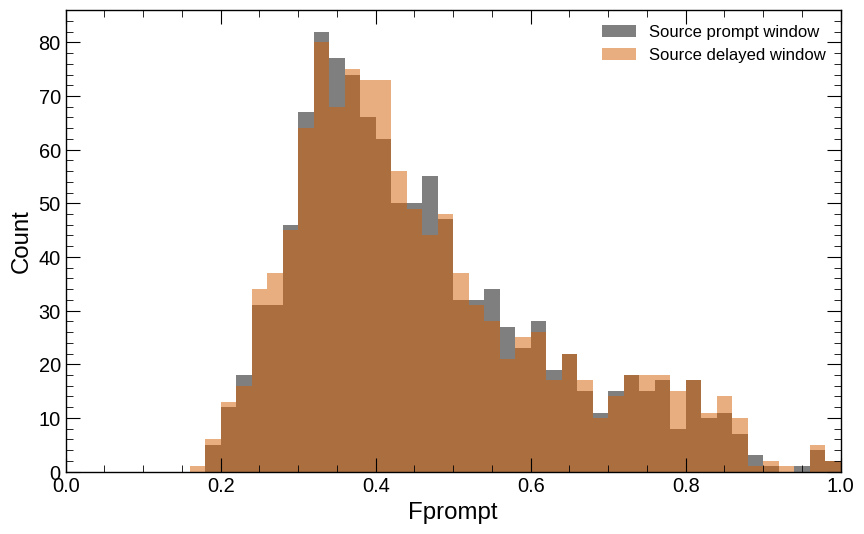

In [15]:
# Plot fprompt distribution for the background events and source events
plt.figure(figsize=(10, 6))
# plt.hist(df[df["delay"] == -1]["fprompt"], bins=bins, alpha=0.5, label="Background", color="blue")
# Only R1
plt.hist(df[(df["delay"] != -1) & (df["R"] == "R1")]["fprompt"], bins=bins, alpha=0.5, label="Source prompt window")
# Only R2
plt.hist(df[(df["delay"] != -1) & (df["R"] == "R2")]["fprompt"], bins=bins, alpha=0.5, label="Source delayed window")
plt.xlabel("Fprompt")
plt.ylabel("Count")
plt.xlim(0,1)
plt.legend()
plt.show()

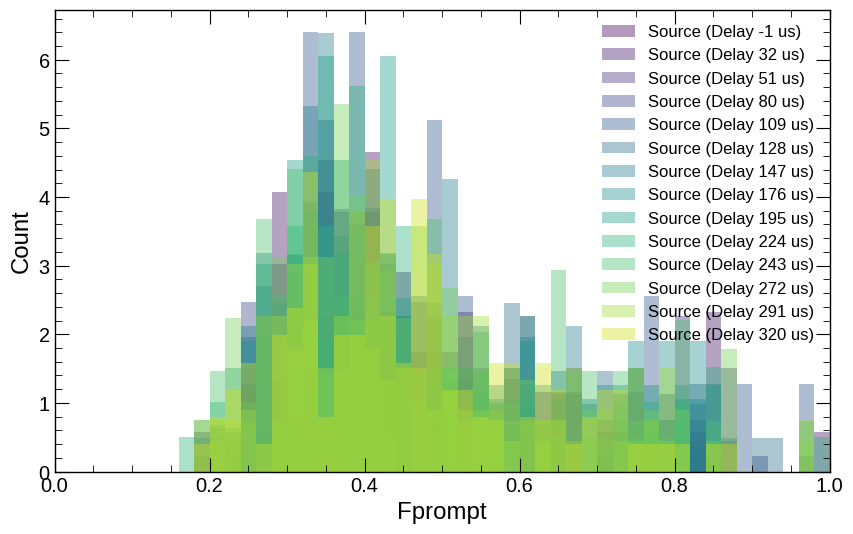

In [18]:
# Plot fprompt distribution for the background events and source events split by delay
# get 15 sequential colors from the cividis colormap
colors = plt.cm.viridis(np.linspace(0, 1, 15))
plt.figure(figsize=(10, 6))
i=0
for delay in sorted(df["delay"].unique()):
    background = df[df["delay"] == -1]
    subset = df[(df["delay"] == delay) & (df["R"] == "R2")]
    label = f"Source (Delay {delay} us)"
    plt.hist(subset["fprompt"], bins=bins, alpha=0.4, label=label, color=colors[i], density=True)
    i+=1
# plt.hist(background["fprompt"], bins=bins, alpha=0.5, label="Background", color="blue", density=True)
plt.xlabel("Fprompt")
plt.ylabel("Count")
plt.xlim(0,1)
plt.legend()
plt.show()

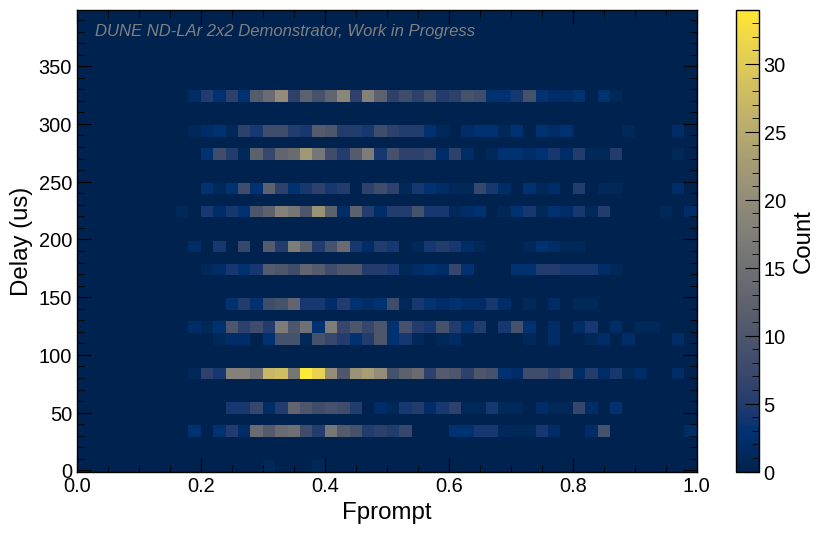

In [30]:
# Turn it into a 2d histogram instead
_LABEL_TEXT = "DUNE ND-LAr 2x2 Demonstrator, Work in Progress"
fig, ax = plt.subplots(figsize=(10, 6))
plt.hist2d(df["fprompt"],df["delay"], bins=[bins, np.arange(-1, 400, 10)])
plt.xlim(0,1)
plt.xlabel("Fprompt")
plt.ylabel("Delay (us)")
ax.text(0.03, 0.97, _LABEL_TEXT, transform=ax.transAxes,
            fontsize=12, fontstyle="italic",
            ha="left", va="top", color="gray")
plt.colorbar(label="Count")
plt.show()

In [18]:
subset["fprompt"].mean()

np.float64(0.4609601277777778)

In [19]:
len(subset.dropna())

126

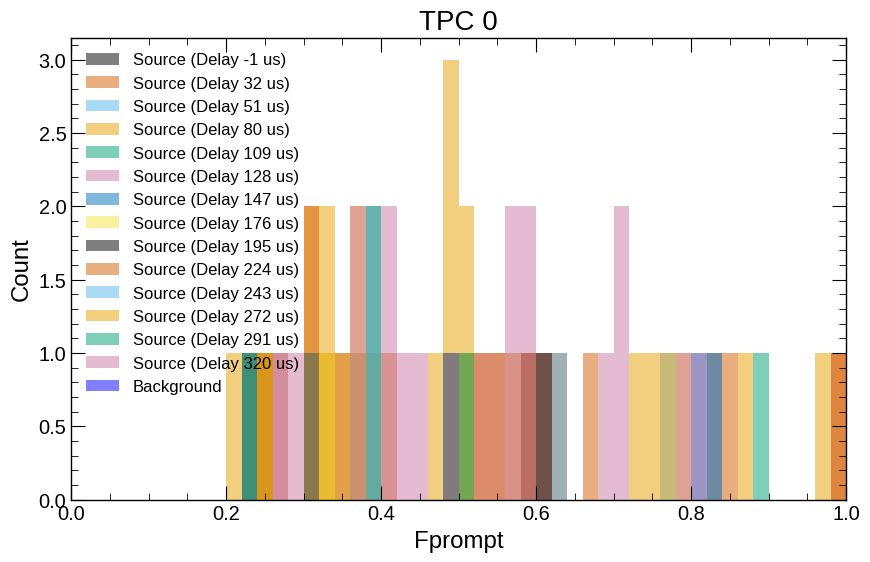

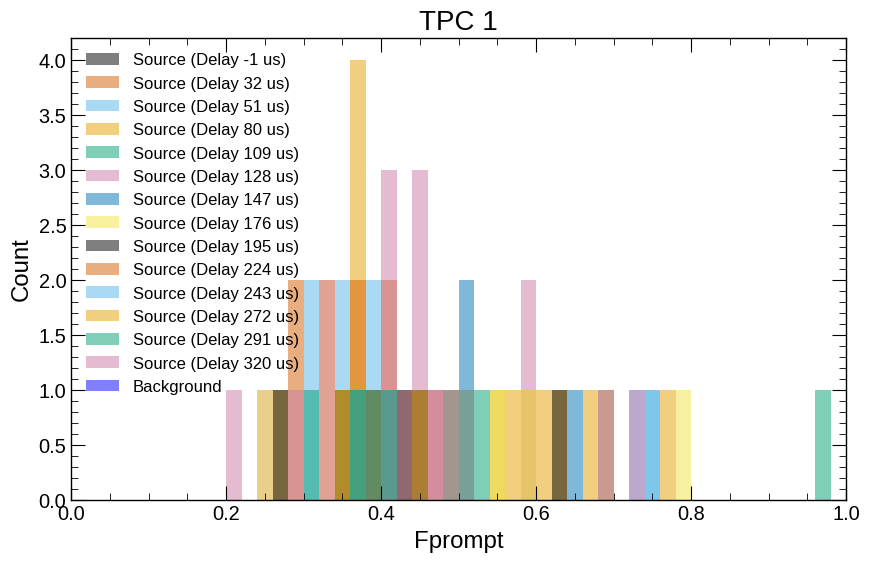

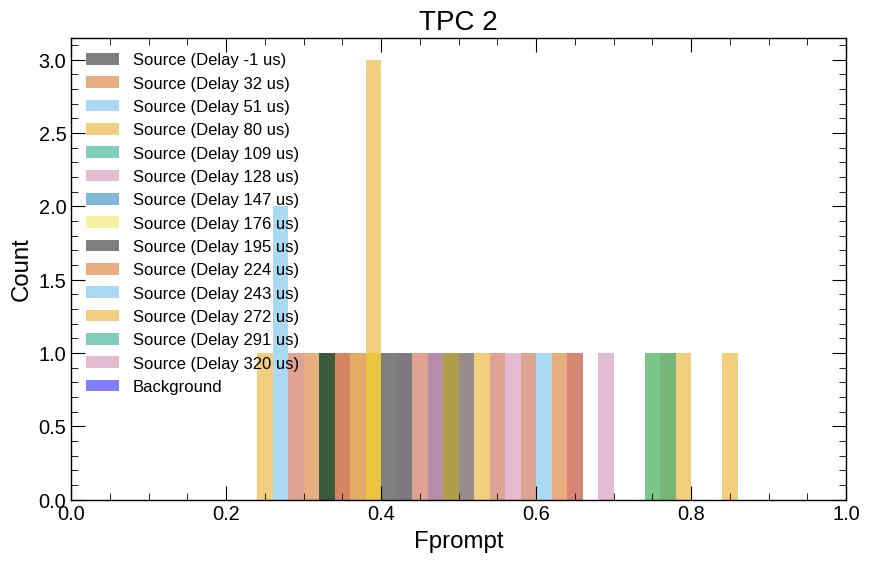

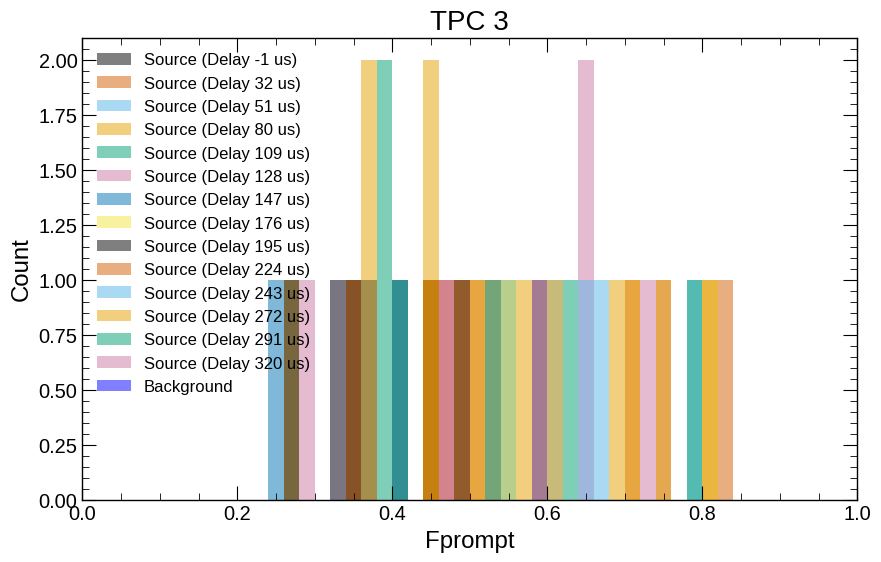

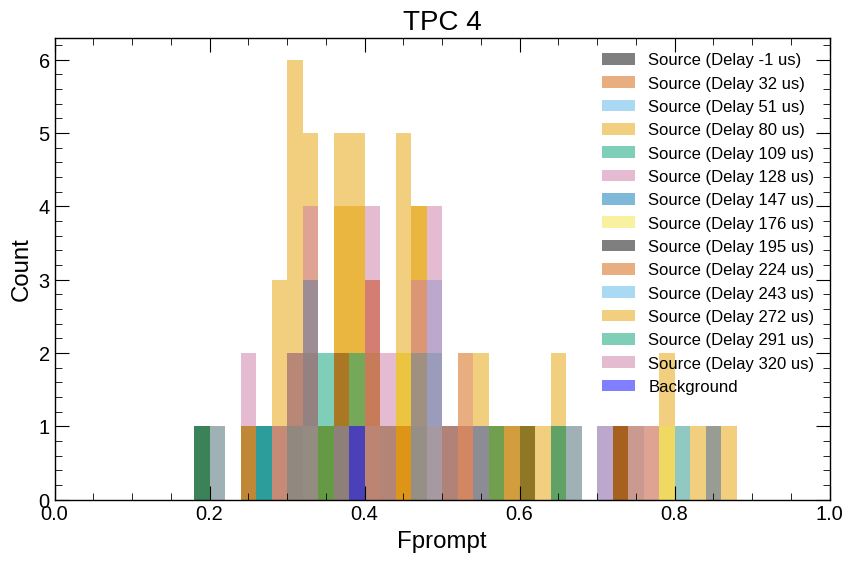

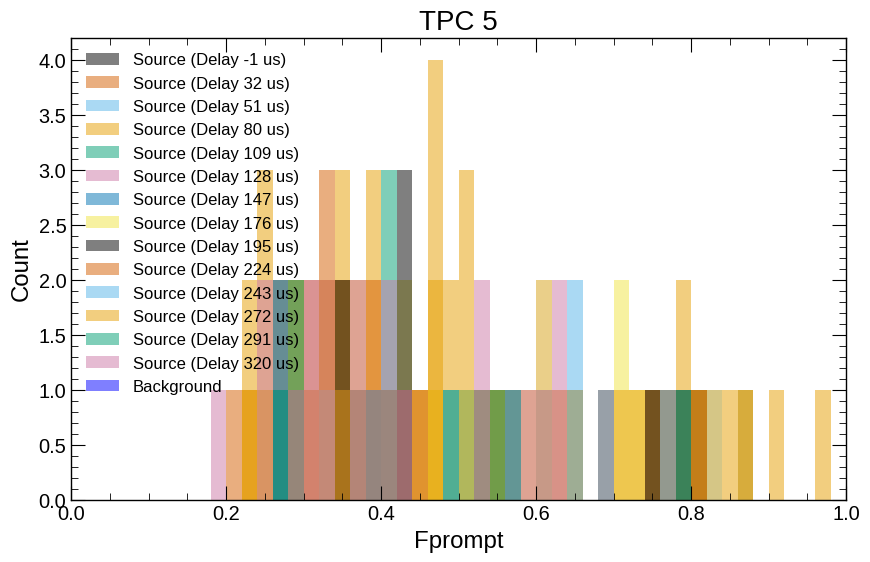

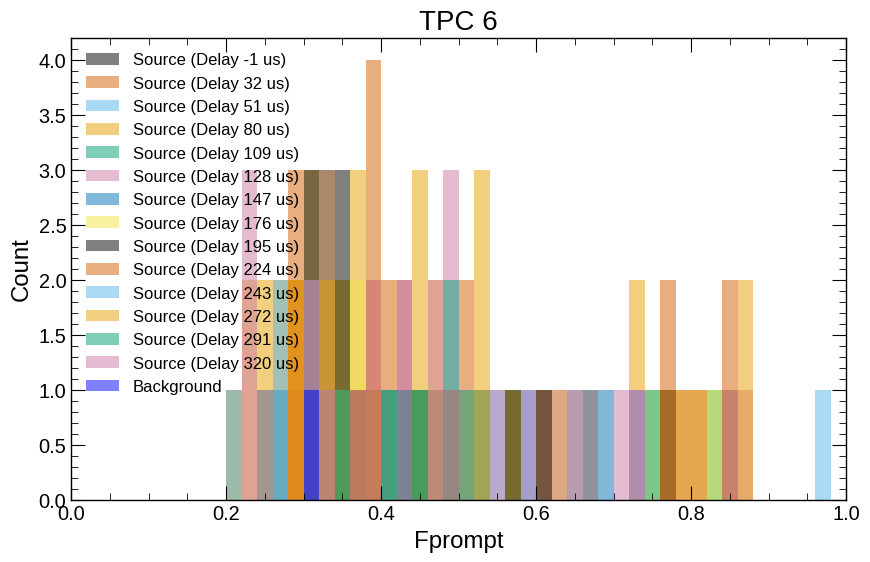

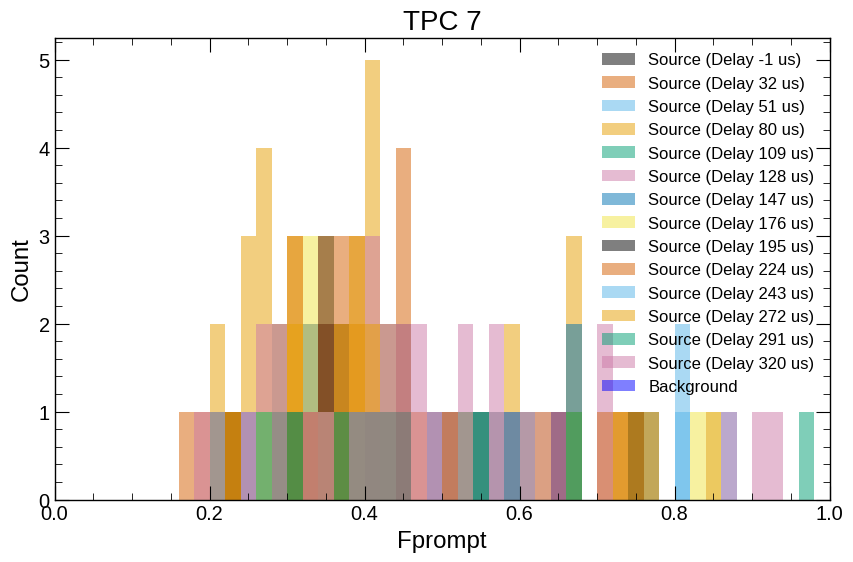

/global/homes/m/mnuland/.conda/envs/myenv/lib/python3.12/site-packages/matplotlib/axes/_axes.py:6834: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/global/homes/m/mnuland/.conda/envs/myenv/lib/python3.12/site-packages/matplotlib/axes/_axes.py:6835: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


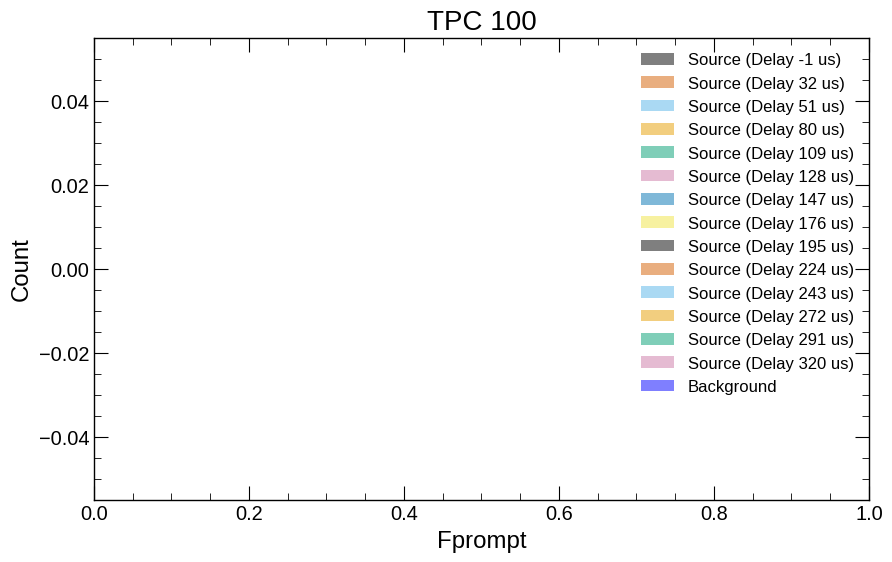

In [20]:
# Split per TPC and make 8 plots
for tpc in sorted(df["tpc"].unique()):
    plt.figure(figsize=(10, 6))
    for delay in sorted(df["delay"].unique()):
        background = df[df["delay"] == -1]
        subset = df[(df["delay"] == delay) & (df["R"] == "R2") & (df["tpc"] == tpc)]
        label = f"Source (Delay {delay} us)"
        plt.hist(subset["fprompt"], bins=bins, alpha=0.5, label=label)
    plt.hist(background[background["tpc"] == tpc]["fprompt"], bins=bins, alpha=0.5, label="Background", color="blue")
    plt.xlabel("Fprompt")
    plt.ylabel("Count")
    plt.xlim(0,1)
    plt.title(f"TPC {tpc}")
    plt.legend()
    plt.show()

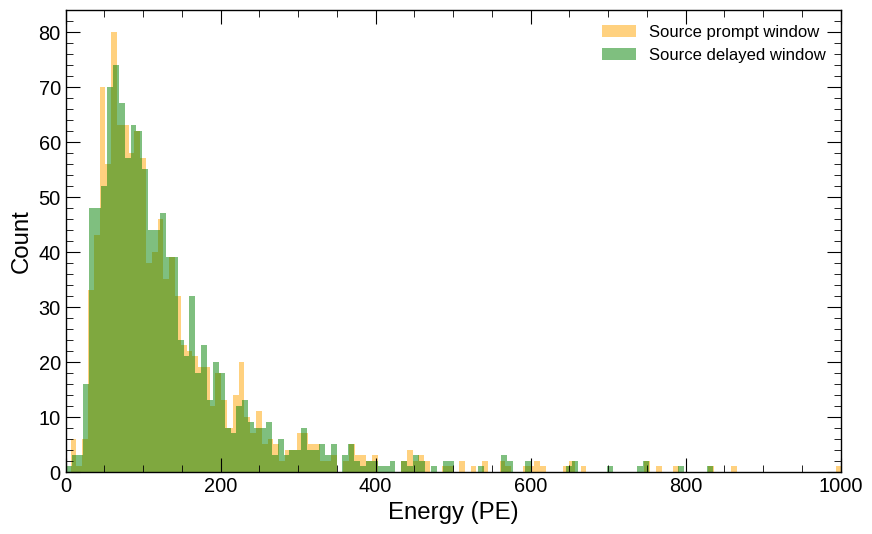

In [21]:
# Plot energy distribution for the background events and source events
plt.figure(figsize=(10, 6))
# plt.hist(df[df["delay"] == -1]["energy"], bins=250, alpha=0.5, label="Background", color="blue")
# Only R1
plt.hist(df[(df["delay"] != -1) & (df["R"] == "R1")]["energy"], bins=250, alpha=0.5, label="Source prompt window", color="orange")
# Only R2
plt.hist(df[(df["delay"] != -1) & (df["R"] == "R2")]["energy"], bins=250, alpha=0.5, label="Source delayed window", color="green")
plt.xlabel("Energy (PE)")
plt.ylabel("Count")
plt.xlim(0,1000)
plt.legend()
plt.show()

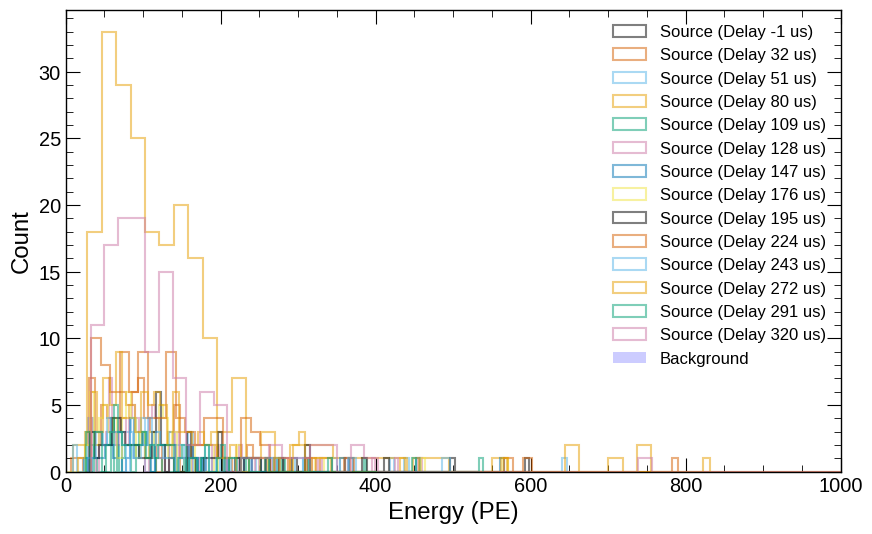

In [22]:
# Plot energy distribution for the background events and source events split by delay
plt.figure(figsize=(10, 6))
for delay in sorted(df["delay"].unique()):
    background = df[df["delay"] == -1]
    subset = df[(df["delay"] == delay) & (df["R"] == "R2")]
    label = f"Source (Delay {delay} us)"
    plt.hist(subset["energy"], bins=100, alpha=0.5, label=label, histtype="step")
plt.hist(background["energy"], bins=100, alpha=0.2, label="Background", color="blue")
plt.xlabel("Energy (PE)")
plt.ylabel("Count")
plt.xlim(0,1000)
plt.legend()
plt.show()

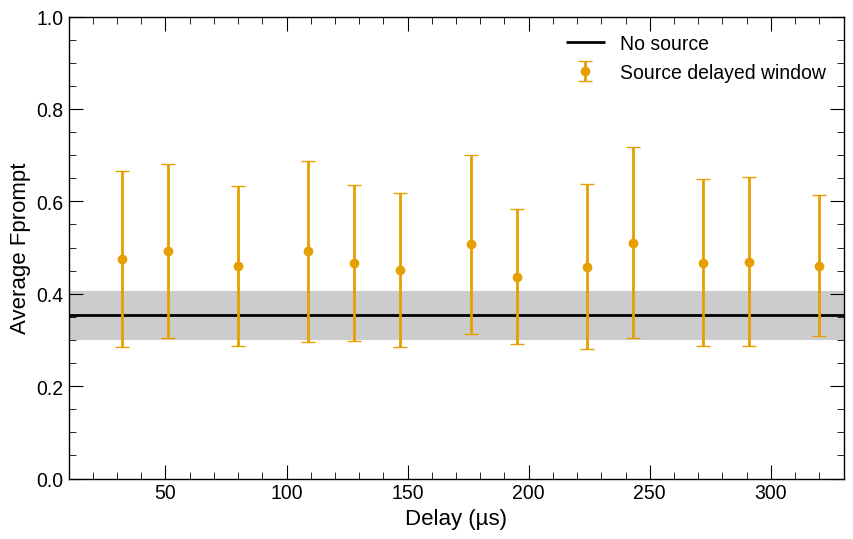

In [39]:
# Calculate average fprompt for each delay and uncertainty
average_fprompt = df[df["R"]=="R2"].groupby("delay")["fprompt"].mean()
std_fprompt = df[df["R"]=="R2"].groupby("delay")["fprompt"].std()

# And for the background
average_fprompt[-1] = df[df["delay"]==-1]["fprompt"].mean()
std_fprompt[-1] = df[df["delay"]==-1]["fprompt"].std()

# Plot average fprompt vs delay with error bars
fig, ax = plt.subplots(figsize=(10, 6))

ax.hlines(xmin=-1, xmax=max(df["delay"].unique())+10, y=average_fprompt[-1], alpha=1, label="No source")
ax.fill_between([-1, max(df["delay"].unique())+10], average_fprompt[-1] - std_fprompt[-1], average_fprompt[-1] + std_fprompt[-1], alpha=0.2)

ax.errorbar(average_fprompt.index, average_fprompt, yerr=std_fprompt, fmt="o", color="#E69F00", capsize=5, label="Source delayed window")

ax.set_xlabel("Delay (µs)", fontsize=16)
ax.set_ylabel("Average Fprompt", fontsize=16)
ax.legend(fontsize=14)
ax.tick_params(axis='both', direction='in', labelsize=14)
ax.set_ylim(0,1)
ax.set_xlim(10, max(df["delay"].unique())+10)
plt.show()

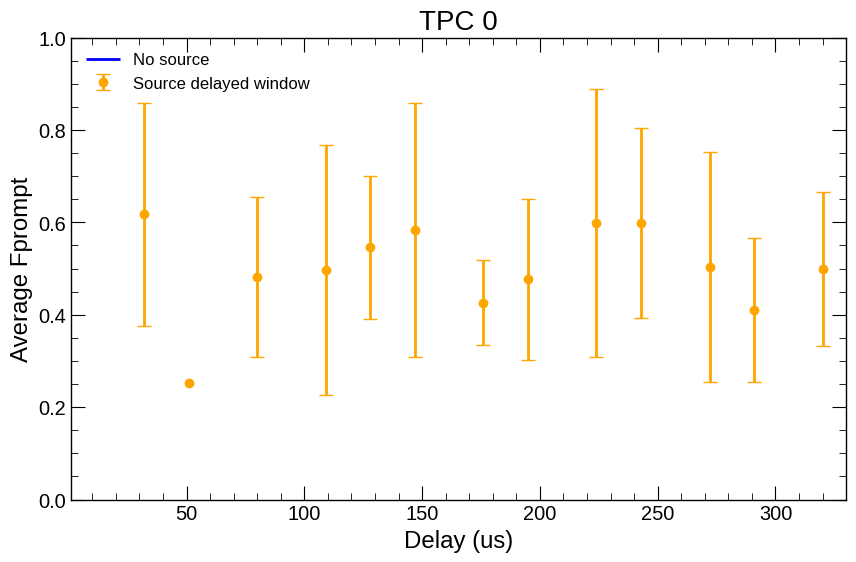

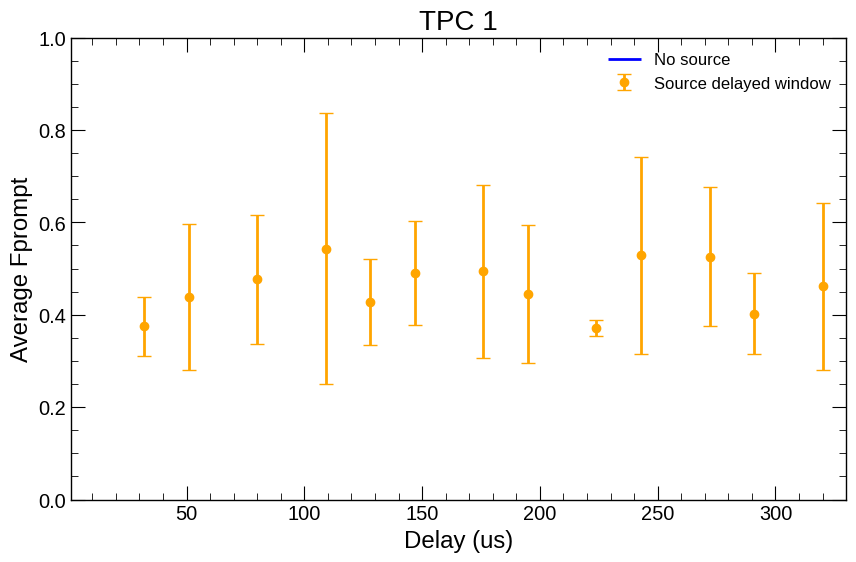

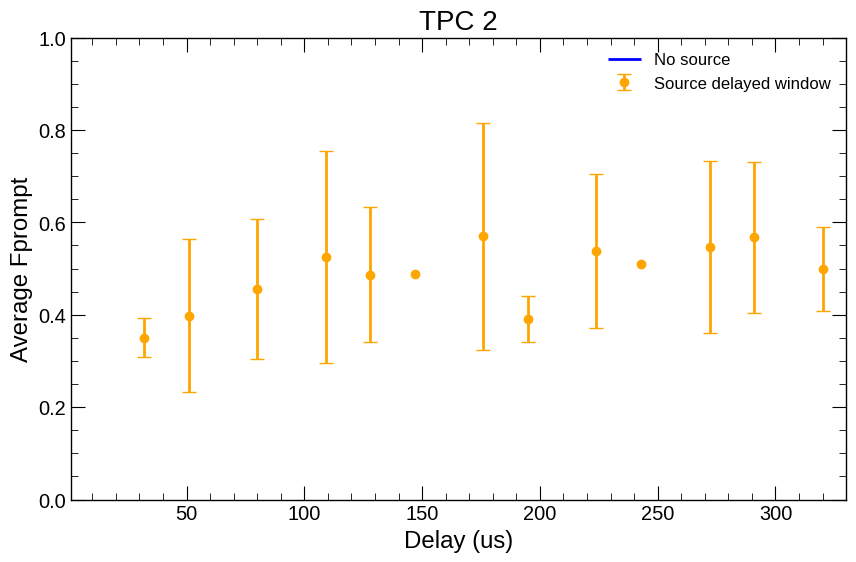

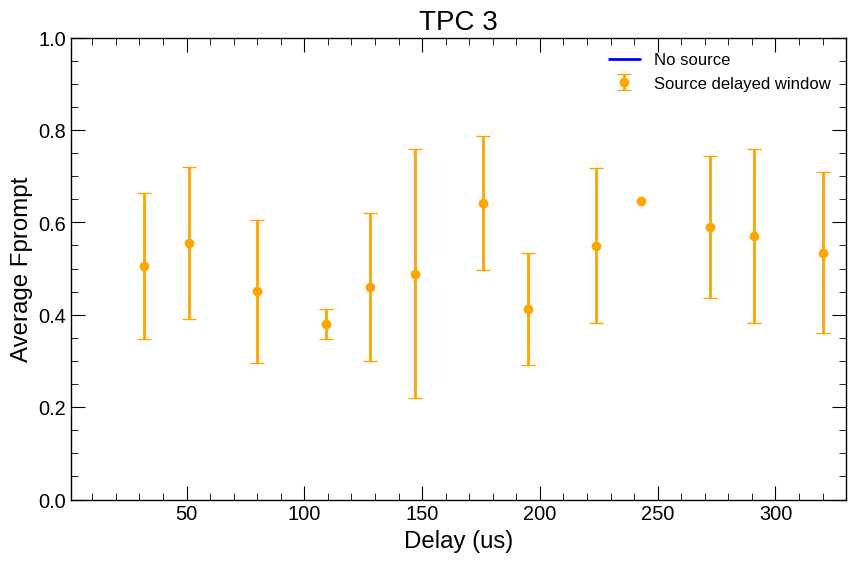

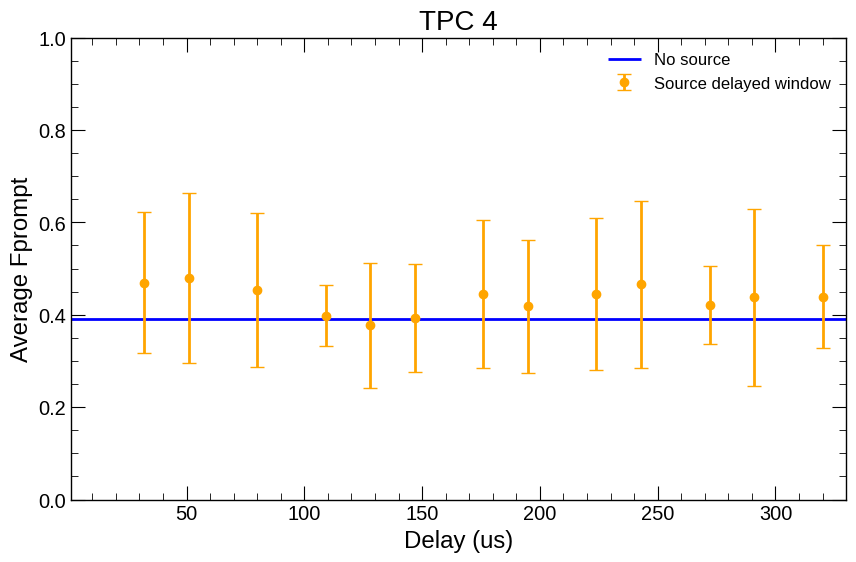

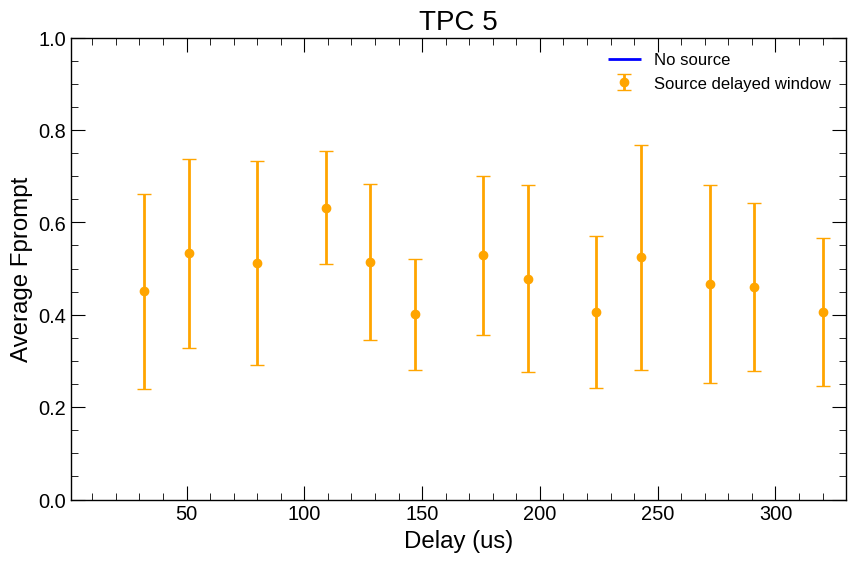

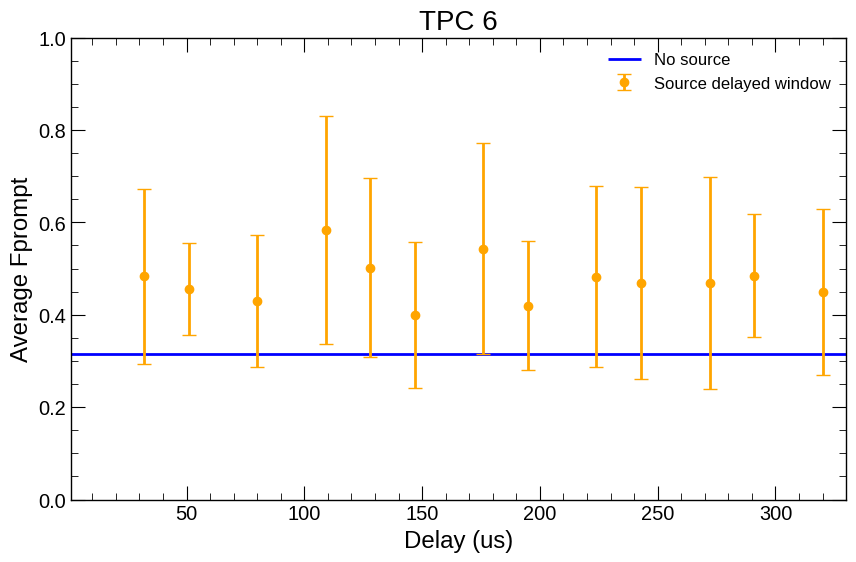

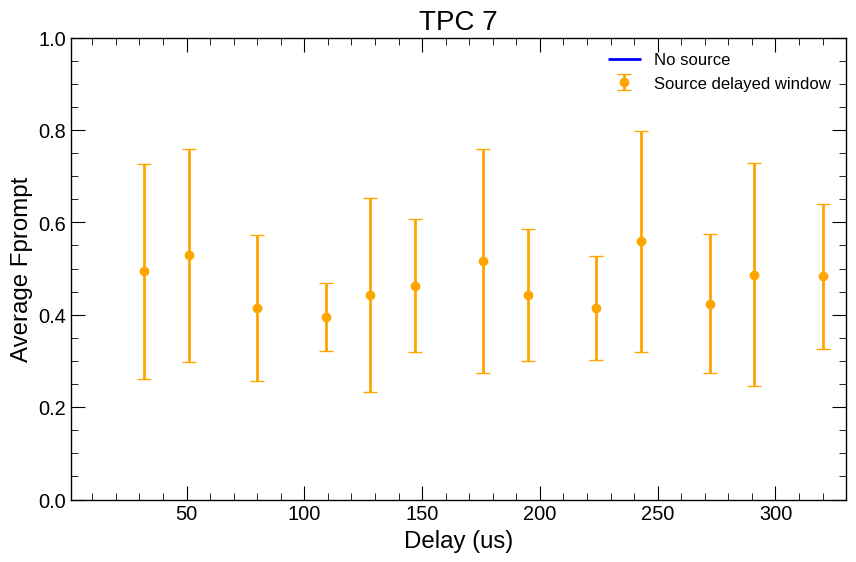

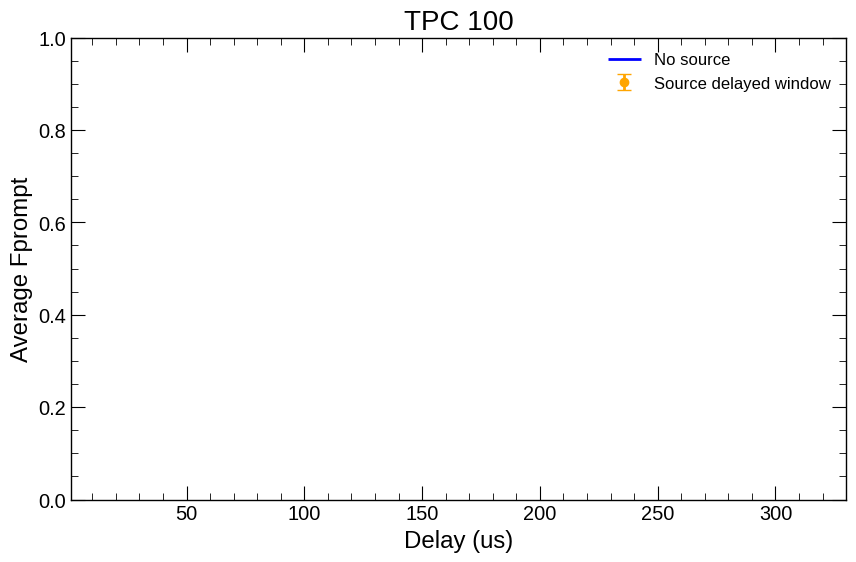

In [32]:
# Split per TPC and make 8 plots
for tpc in sorted(df["tpc"].unique()):
    fig, ax = plt.subplots(figsize=(10, 6))

    background = df[df["delay"] == -1]
    subset = df[(df["R"] == "R2") & (df["tpc"] == tpc)]
    
    average_fprompt = subset.groupby("delay")["fprompt"].mean()
    std_fprompt = subset.groupby("delay")["fprompt"].std()
    
    average_fprompt[-1] = background[background["tpc"] == tpc]["fprompt"].mean()
    std_fprompt[-1] = background[background["tpc"] == tpc]["fprompt"].std()

    ax.hlines(xmin=-1, xmax=max(subset["delay"].unique())+10, y=average_fprompt[-1], color="blue", label="No source")
    ax.fill_between([-1, max(subset["delay"].unique())+10], average_fprompt[-1] - std_fprompt[-1], average_fprompt[-1] + std_fprompt[-1], color="blue", alpha=0.2)

    ax.errorbar(average_fprompt.index, average_fprompt, yerr=std_fprompt, fmt="o", capsize=5, color="orange", label="Source delayed window")

    ax.set_xlabel("Delay (us)")
    ax.set_ylabel("Average Fprompt")
    ax.set_title(f"TPC {tpc}")
    ax.legend()

    ax.set_ylim(0,1)
    ax.set_xlim(1, max(subset["delay"].unique())+10)
    plt.show()

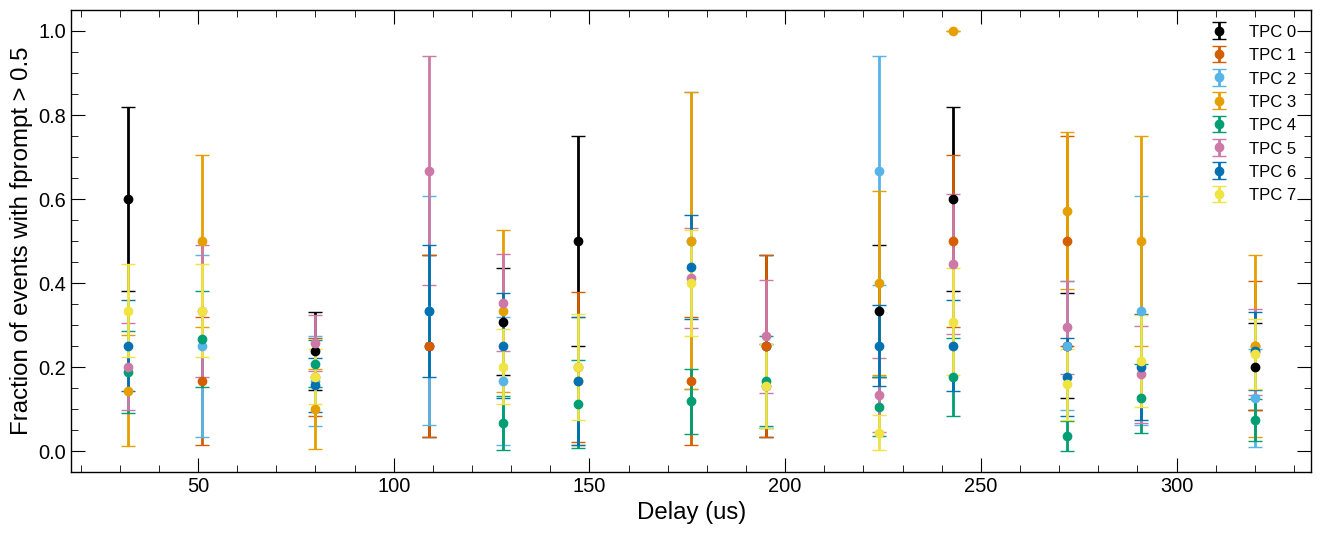

In [45]:
# Per delay, per tpc calculate the fraction of events with fprompt > 0.5 and plot that vs delay with error bars
df = df.dropna()
num_events = df[(df["R"] == "R2")].groupby(["delay", "tpc"]).size()
num_events_high = df[(df["R"] == "R2") & (df["fprompt"] > 0.6)].groupby(["delay", "tpc"]).size()
ratio = num_events_high / num_events
# Calculate the uncertainty on the ratio using binomial error
uncertainty = np.sqrt(ratio * (1 - ratio) / num_events)
# plot the ratio vs delay with error bars, and make a separate line for each tpc
fig, ax = plt.subplots(figsize=(16, 6))
for tpc in sorted(df["tpc"].unique()):
    subset = ratio.xs(tpc, level="tpc")
    subset_uncertainty = uncertainty.xs(tpc, level="tpc")
    ax.errorbar(subset.index, subset, yerr=subset_uncertainty, fmt="o", capsize=5, label=f"TPC {tpc}")
ax.set_xlabel("Delay (us)")
ax.set_ylabel("Fraction of events with fprompt > 0.5")
ax.legend()
plt.show()


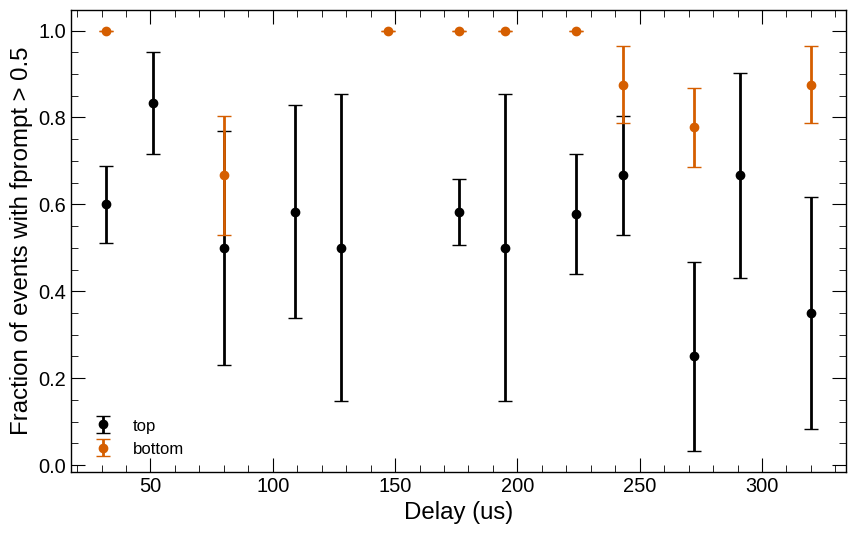

In [46]:
# Make the same plot, but consider TPC 6 to be signal and everything else background
df = df.dropna()
num_events = df[df["R"] == "R2"].groupby(["delay", "det", "tpc"]).size()
num_events_high = df[(df["R"] == "R2") & (df["fprompt"] > 0.5) & (df["det"].isin([0,1,2,3,8,9,10,11]))&(df["tpc"].isin([6]))].groupby(["delay", "det", "tpc"]).size()
num_events_high_tpc = df[(df["R"] == "R2") & (df["fprompt"] > 0.5)& (df["det"].isin([4,5,6,7,12,13,14,15]))&(df["tpc"].isin([6]))].groupby(["delay", "det", "tpc"]).size()

ratio = num_events_high / num_events
ratio_tpc = num_events_high_tpc / num_events
uncertainty = np.sqrt(ratio * (1 - ratio) / num_events)
uncertainty_tpc = np.sqrt(ratio_tpc * (1 - ratio_tpc) / num_events)
fig, ax = plt.subplots(figsize=(10, 6))
# subset = ratio.xs(6, level="tpc")
# subset_uncertainty = uncertainty.xs(6, level="tpc")

ratio_tpc.groupby("delay").mean().plot(yerr=uncertainty_tpc.groupby("delay").mean(), fmt="o", capsize=5, label="top")

# fit a line through the tpc 6 points
# fit = np.polyfit(subset.index, subset, 1)
# plot the fit line
# ax.plot(subset.index, fit[0]*subset.index + fit[1], label="Fit line for TPC 6", color="tab:orange")

# fit a line through the other tpcs
# fit_tpc = np.polyfit(ratio_tpc.groupby("delay").mean().index, ratio_tpc.groupby("delay").mean(), 1)
# ax.plot(ratio_tpc.groupby("delay").mean().index, fit_tpc[0]*ratio_tpc.groupby("delay").mean().index + fit_tpc[1], label="Fit line for other TPCs", color="tab:blue")

ax.errorbar(ratio.groupby("delay").mean().index, ratio.groupby("delay").mean(), yerr=uncertainty.groupby("delay").mean(), fmt="o", capsize=5, label=f"bottom")
ax.set_xlabel("Delay (us)")
ax.set_ylabel("Fraction of events with fprompt > 0.5")
ax.legend()
plt.show()

# check if the difference in slope is significant by calculating the uncertainty on the slope using the covariance matrix from np.polyfit
# cov = np.polyfit(subset.index, subset, 1, cov=True)[1]
# slope_uncertainty = np.sqrt(cov[0][0])
# cov_tpc = np.polyfit(ratio_tpc.groupby("delay").mean().index, ratio_tpc.groupby("delay").mean(), 1, cov=True)[1]
# slope_uncertainty_tpc = np.sqrt(cov_tpc[0][0])
# print(f"Slope for TPC 6: {fit[0]:.4f} ± {slope_uncertainty:.4f}")
# print(f"Slope for other TPCs: {fit_tpc[0]:.4f} ± {slope_uncertainty_tpc:.4f}")
# # calculate the significance of the difference in slope
# slope_diff = fit[0] - fit_tpc[0]
# slope_diff_uncertainty = np.sqrt(slope_uncertainty**2 + slope_uncertainty_tpc**2)
# significance = slope_diff / slope_diff_uncertainty
# print(f"Difference in slope: {slope_diff:.4f} ± {slope_diff_uncertainty:.4f} (Significance: {significance:.2f} sigma)")

# # also calculate the significance of the difference in ratio over all delays
# ratio_diff = ratio_tpc.groupby("delay").mean() - ratio.xs(6, level="tpc")
# ratio_diff_uncertainty = np.sqrt(uncertainty_tpc.groupby("delay").mean()**2 + uncertainty.xs(6, level="tpc")**2)
# significance_ratio = ratio_diff / ratio_diff_uncertainty
# print(f"Difference in ratio: {ratio_diff.mean():.4f} ± {ratio_diff_uncertainty.mean():.4f} (Significance: {significance_ratio.mean():.2f} sigma)")


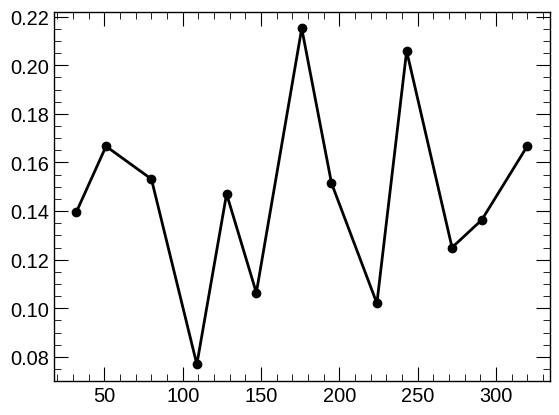

In [47]:
# select the events with fprompt between 0.6 and 0.8
df =df.dropna()
subset = df[(df["R"] == "R2") & (df["fprompt"] > 0.6) & (df["fprompt"] < 0.8)]
ratio = subset.groupby("delay").size()/df[(df["R"] == "R2")].groupby("delay").size()

plt.plot(ratio.index, ratio, marker="o")

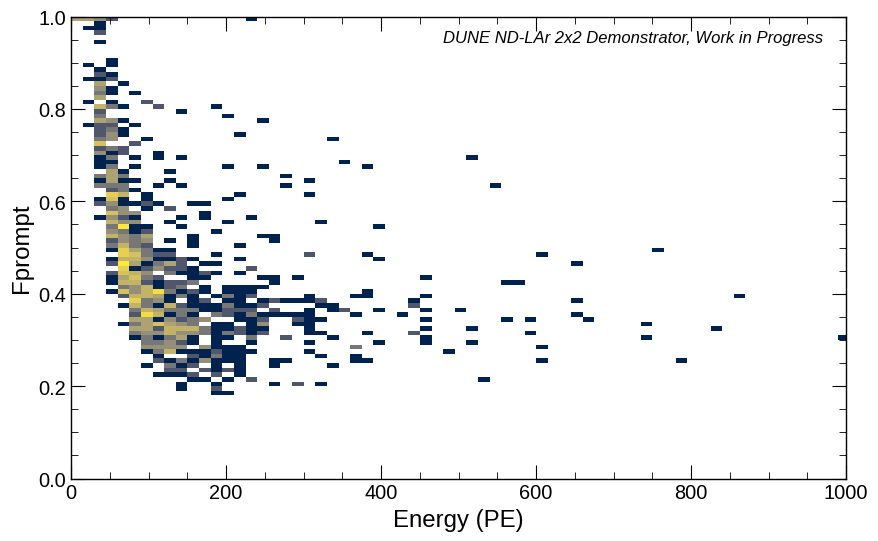

In [48]:
# plot fprompt vs energy in a 2d heatmap
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(figsize=(10, 6))
df_nona = df.dropna(subset=["fprompt", "energy"])
df_R1 = df[df["R"]=="R1"]
plt.hist2d(df_nona[df_nona["R"]=="R1"]["energy"], df_nona[df_nona["R"]=="R1"]["fprompt"], bins=100, range=[[0,1500], [0,1]], norm=LogNorm())
# plt.hist2d(df_R1["energy"], df_R1["fprompt"], bins=100, cmap="plasma", norm=LogNorm(), alpha=0.5)
plt.xlim(0,1000)
plt.ylim(0,1)
dune_label(ax, loc="upper right")
plt.xlabel("Energy (PE)")
plt.ylabel("Fprompt")
plt.show()

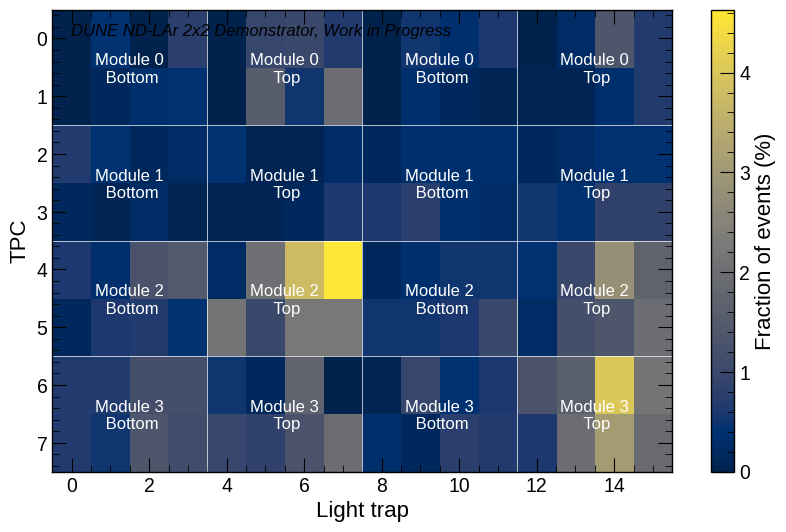

In [49]:
# which tpc has most activity?
activity = df[df["R"]=="R1"].groupby("tpc").size()
# which detector in which tpc has most activity?
activity_det = df[df["R"]=="R1"].groupby(["tpc", "det"]).size().unstack(fill_value=0)
# make 2d heatmap of activity per detector per tpc (percentage)
total = activity_det.values.sum()
activity_pct = 100 * activity_det / total
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(activity_pct, aspect="auto")

ax.vlines(x=[3.5, 7.5, 11.5], ymin=7.5, ymax=-0.5, colors="white", linewidth=0.5)
ax.hlines(y=[1.5, 3.5, 5.5], xmin=-0.5, xmax=15.5, colors="white", linewidth=0.5)
# annotate each module and top or bottom
plt.annotate("Module 0\n Bottom", xy=(1.5, -0.5), xytext=(1.5, 0.25), ha="center", va="top", fontsize=12, color="white")
plt.annotate("Module 0\n Top", xy=(5.5, -0.5), xytext=(5.5, 0.25), ha="center", va="top", fontsize=12, color="white")
plt.annotate("Module 0\n Bottom", xy=(9.5, -0.5), xytext=(9.5, 0.25), ha="center", va="top", fontsize=12, color="white")
plt.annotate("Module 0\n Top", xy=(13.5, -0.5), xytext=(13.5, 0.25), ha="center", va="top", fontsize=12, color="white")

plt.annotate("Module 1\n Bottom", xy=(1.5, -0.5), xytext=(1.5, 2.25), ha="center", va="top", fontsize=12, color="white")
plt.annotate("Module 1\n Top", xy=(5.5, -0.5), xytext=(5.5, 2.25), ha="center", va="top", fontsize=12, color="white")
plt.annotate("Module 1\n Bottom", xy=(9.5, -0.5), xytext=(9.5, 2.25), ha="center", va="top", fontsize=12, color="white")
plt.annotate("Module 1\n Top", xy=(13.5, -0.5), xytext=(13.5, 2.25), ha="center", va="top", fontsize=12, color="white")

plt.annotate("Module 2\n Bottom", xy=(1.5, -0.5), xytext=(1.5, 4.25), ha="center", va="top", fontsize=12, color="white")
plt.annotate("Module 2\n Top", xy=(5.5, -0.5), xytext=(5.5, 4.25), ha="center", va="top", fontsize=12, color="white")
plt.annotate("Module 2\n Bottom", xy=(9.5, -0.5), xytext=(9.5, 4.25), ha="center", va="top", fontsize=12, color="white")
plt.annotate("Module 2\n Top", xy=(13.5, -0.5), xytext=(13.5, 4.25), ha="center", va="top", fontsize=12, color="white")

plt.annotate("Module 3\n Bottom", xy=(1.5, -0.5), xytext=(1.5, 6.25), ha="center", va="top", fontsize=12, color="white")
plt.annotate("Module 3\n Top", xy=(5.5, -0.5), xytext=(5.5, 6.25), ha="center", va="top", fontsize=12, color="white")
plt.annotate("Module 3\n Bottom", xy=(9.5, -0.5), xytext=(9.5, 6.25), ha="center", va="top", fontsize=12, color="white")
plt.annotate("Module 3\n Top", xy=(13.5, -0.5), xytext=(13.5, 6.25), ha="center", va="top", fontsize=12, color="white")

cbar = ax.figure.colorbar(ax.images[0])
plt.xlabel("Light trap", fontsize=16)
plt.ylabel("TPC", fontsize=16)
plt.tick_params(axis='both', direction='in', labelsize=14)
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Fraction of events (%)", fontsize=16)
dune_label(ax, )
plt.show()

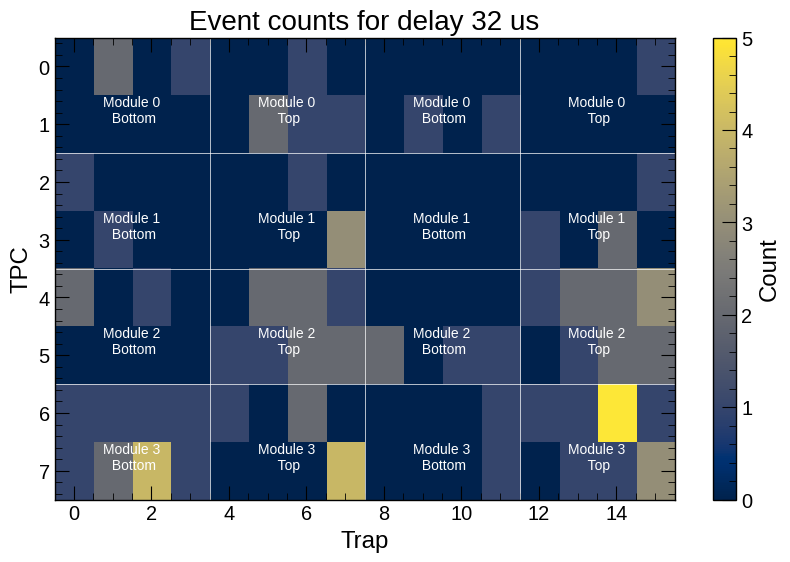

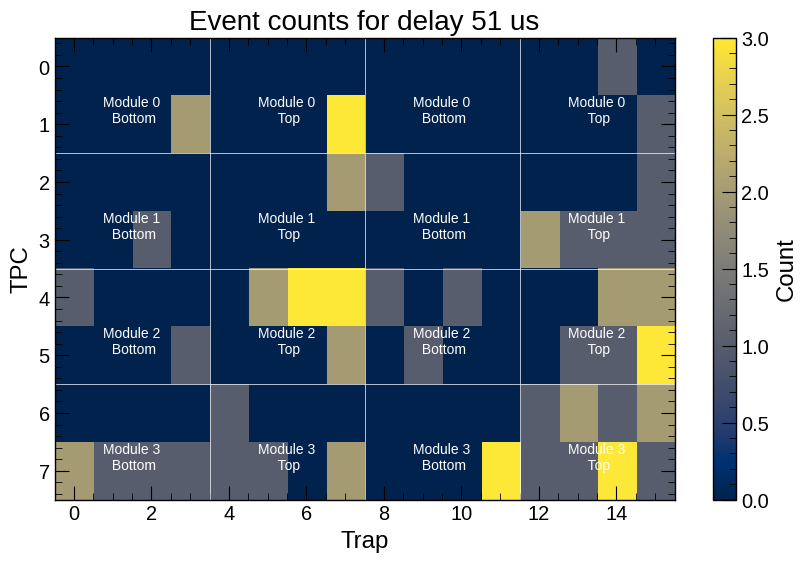

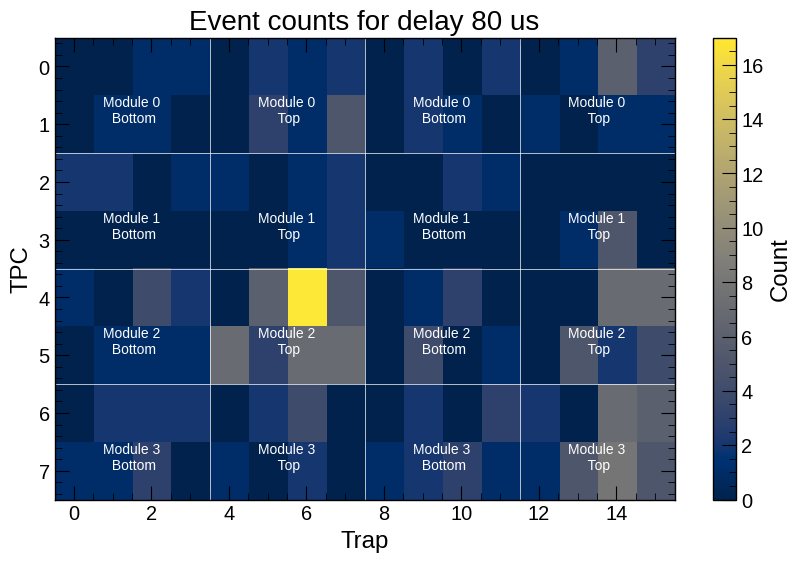

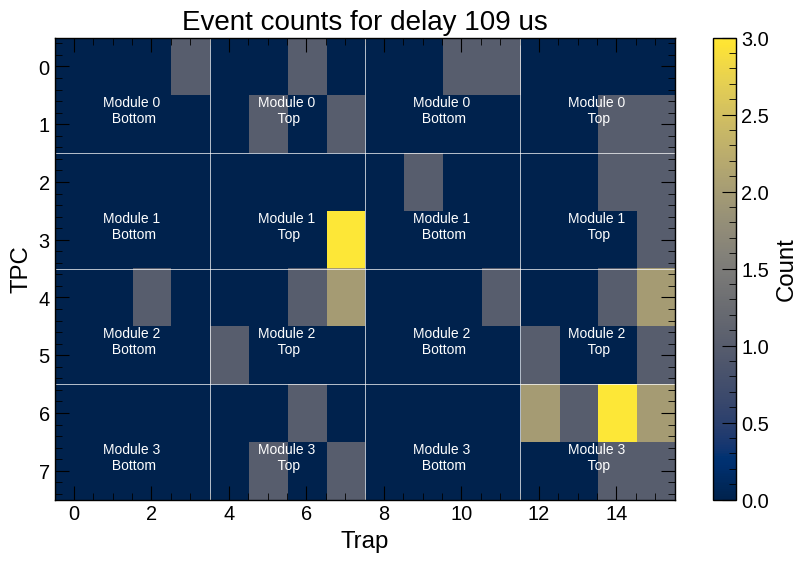

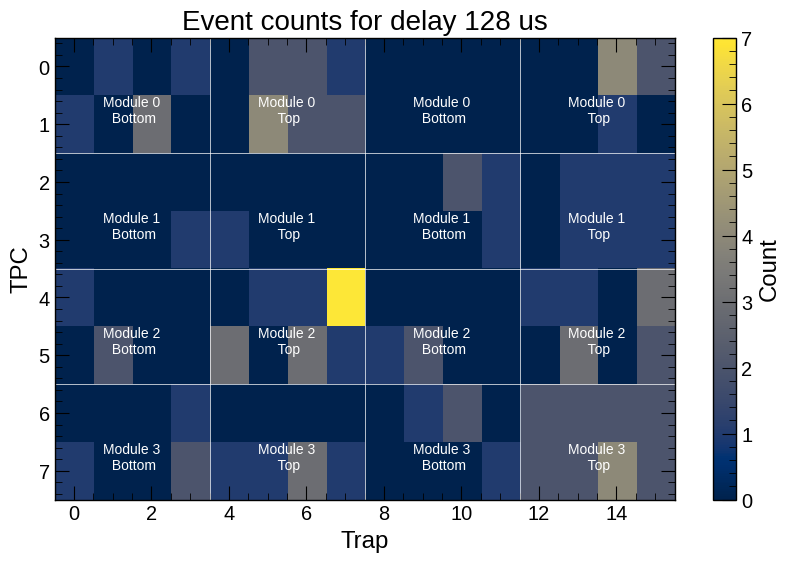

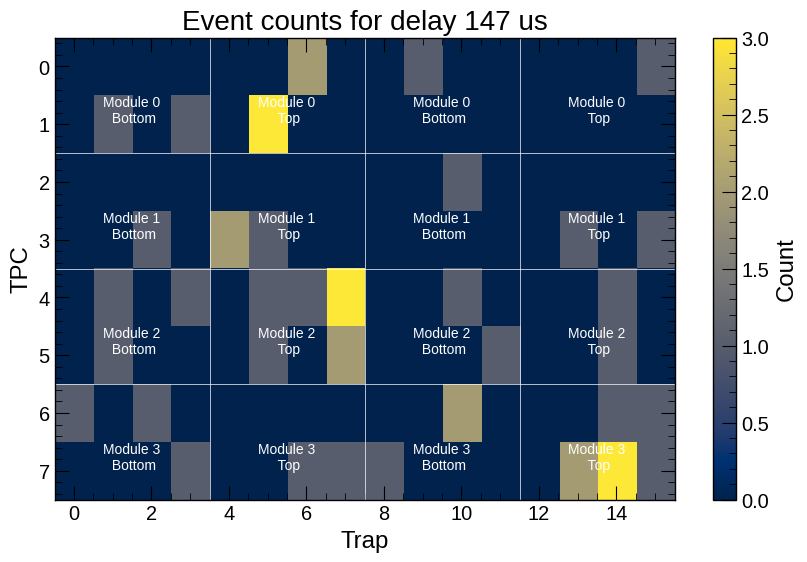

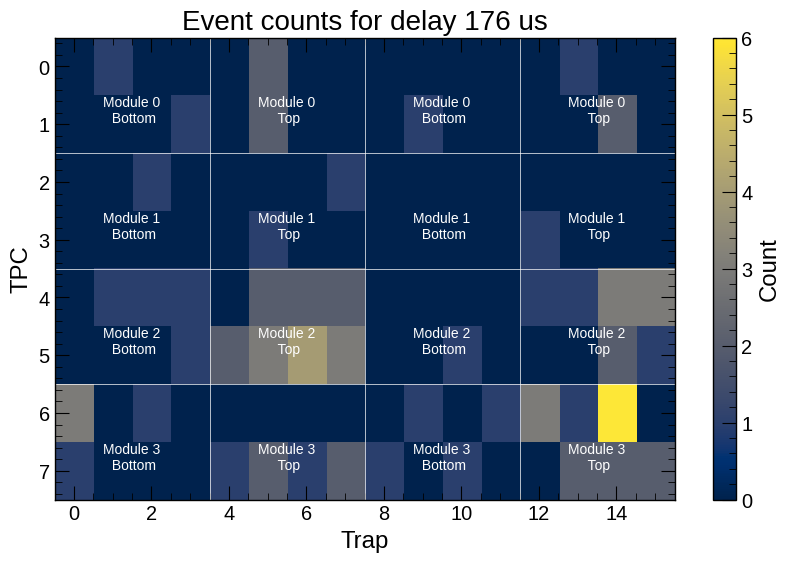

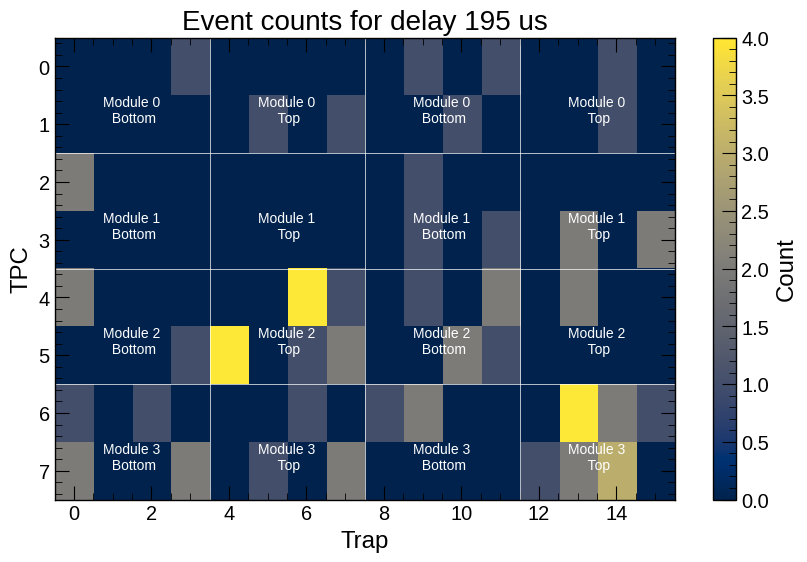

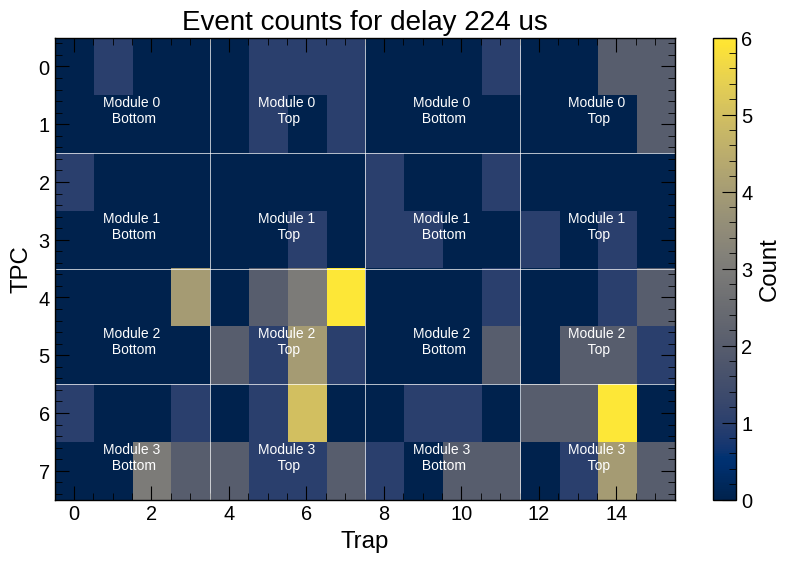

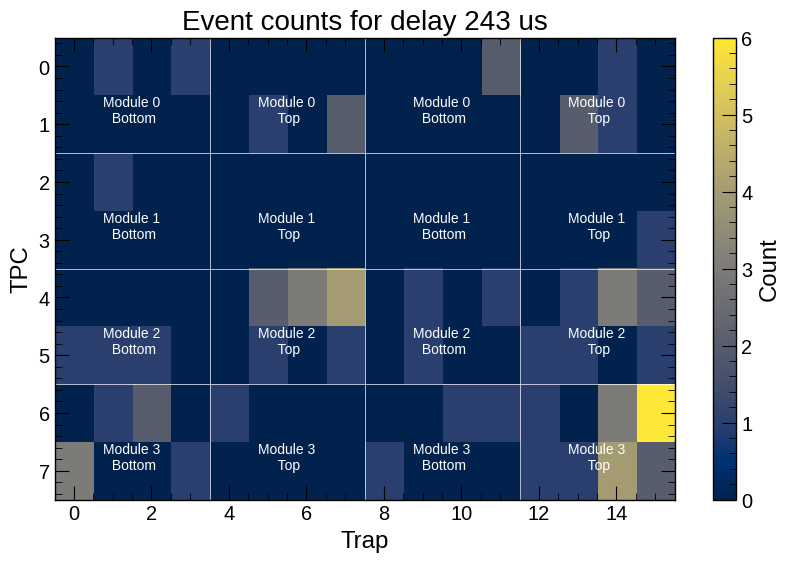

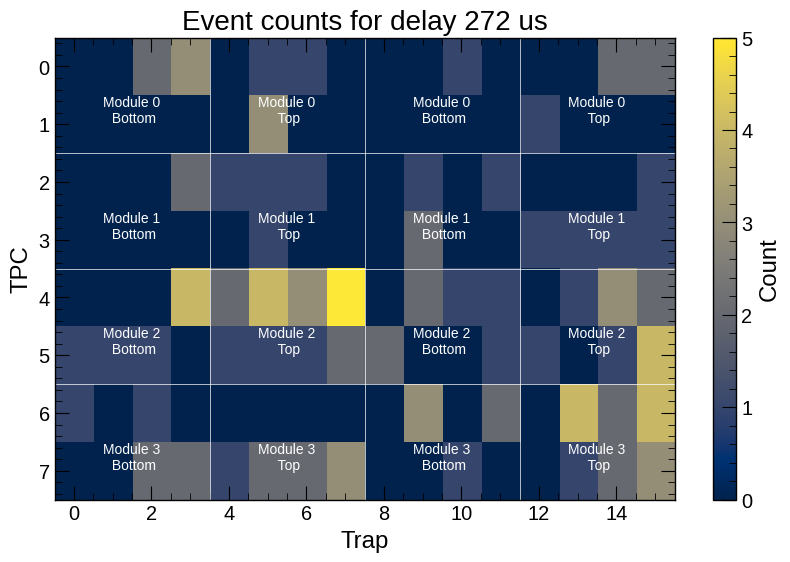

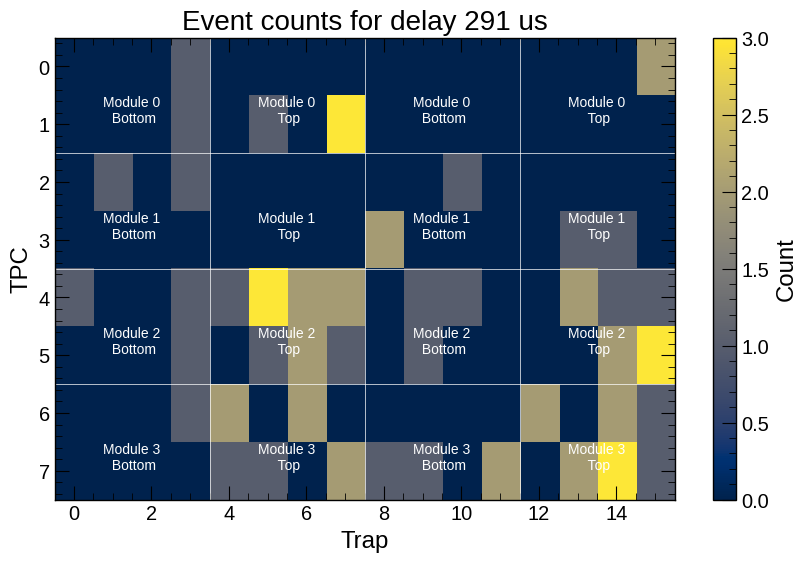

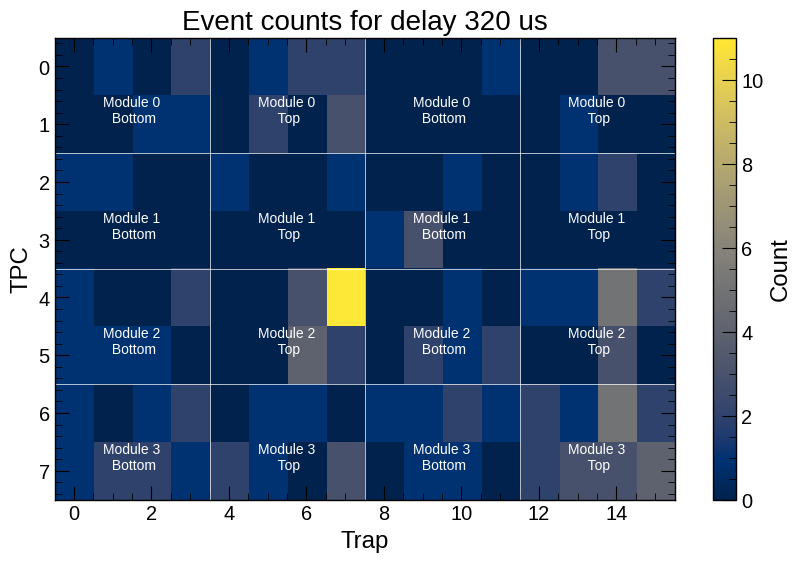

In [50]:
# now, I want to know how many events there are in each time bin, per tpc, per detector
event_counts = df[df["R"]=="R2"].groupby(["delay", "tpc", "det"]).size().unstack(fill_value=0)
# pick a delay and plot the event counts per detector for each tpc
for delay in sorted(df[df["R"]=="R2"]["delay"].unique()):
    delay_to_plot = delay
    plt.figure(figsize=(10, 6))
    plt.imshow(event_counts.xs(delay_to_plot, level="delay"), aspect="auto")
    plt.vlines(x=[3.5, 7.5, 11.5], ymin=7.5, ymax=-0.5, colors="white", linewidth=0.5)
    plt.hlines(y=[1.5, 3.5, 5.5], xmin=-0.5, xmax=15.5, colors="white", linewidth=0.5)
    # annotate each module and top or bottom
    plt.annotate("Module 0\n Bottom", xy=(1.5, -0.5), xytext=(1.5, 0.5), ha="center", va="top", fontsize=10, color="white")
    plt.annotate("Module 0\n Top", xy=(5.5, -0.5), xytext=(5.5, 0.5), ha="center", va="top", fontsize=10, color="white")
    plt.annotate("Module 0\n Bottom", xy=(9.5, -0.5), xytext=(9.5, 0.5), ha="center", va="top", fontsize=10, color="white")
    plt.annotate("Module 0\n Top", xy=(13.5, -0.5), xytext=(13.5, 0.5), ha="center", va="top", fontsize=10, color="white")

    plt.annotate("Module 1\n Bottom", xy=(1.5, -0.5), xytext=(1.5, 2.5), ha="center", va="top", fontsize=10, color="white")
    plt.annotate("Module 1\n Top", xy=(5.5, -0.5), xytext=(5.5, 2.5), ha="center", va="top", fontsize=10, color="white")
    plt.annotate("Module 1\n Bottom", xy=(9.5, -0.5), xytext=(9.5, 2.5), ha="center", va="top", fontsize=10, color="white")
    plt.annotate("Module 1\n Top", xy=(13.5, -0.5), xytext=(13.5, 2.5), ha="center", va="top", fontsize=10, color="white")

    plt.annotate("Module 2\n Bottom", xy=(1.5, -0.5), xytext=(1.5, 4.5), ha="center", va="top", fontsize=10, color="white")
    plt.annotate("Module 2\n Top", xy=(5.5, -0.5), xytext=(5.5, 4.5), ha="center", va="top", fontsize=10, color="white")
    plt.annotate("Module 2\n Bottom", xy=(9.5, -0.5), xytext=(9.5, 4.5), ha="center", va="top", fontsize=10, color="white")
    plt.annotate("Module 2\n Top", xy=(13.5, -0.5), xytext=(13.5, 4.5), ha="center", va="top", fontsize=10, color="white")

    plt.annotate("Module 3\n Bottom", xy=(1.5, -0.5), xytext=(1.5, 6.5), ha="center", va="top", fontsize=10, color="white")
    plt.annotate("Module 3\n Top", xy=(5.5, -0.5), xytext=(5.5, 6.5), ha="center", va="top", fontsize=10, color="white")
    plt.annotate("Module 3\n Bottom", xy=(9.5, -0.5), xytext=(9.5, 6.5), ha="center", va="top", fontsize=10, color="white")
    plt.annotate("Module 3\n Top", xy=(13.5, -0.5), xytext=(13.5, 6.5), ha="center", va="top", fontsize=10, color="white")
    plt.colorbar(label="Count")
    plt.title(f"Event counts for delay {delay_to_plot} us")
    plt.xlabel("Trap")
    plt.ylabel("TPC")
    plt.show()

In [51]:
# make two groups top and bottom, and aggregate event_counts by these groups
event_counts_grouped = event_counts.copy()
event_counts_grouped["top"] = event_counts[[4,5,6,7,12,13,14,15]].sum(axis=1)
event_counts_grouped["bottom"] = event_counts[[0,1,2,3,8,9,10,11]].sum(axis=1)


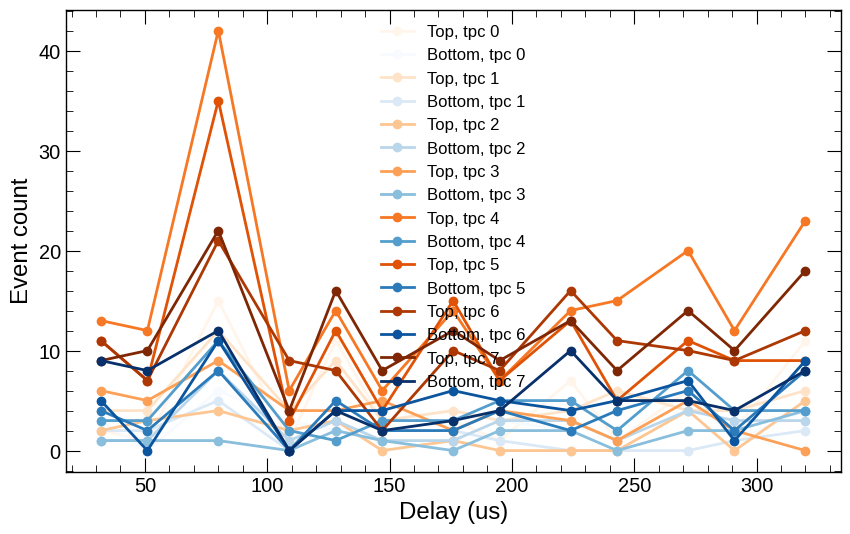

In [52]:
# now plot the top and bottom counts vs delay per tpc
# two colorscales
bottom_colors = plt.cm.Blues(np.linspace(0, 1, len(df["tpc"].unique())))
top_colors = plt.cm.Oranges(np.linspace(0, 1, len(df["tpc"].unique())))

plt.figure(figsize=(10, 6))
for tpc in sorted(df["tpc"].unique()):
    subset_top = event_counts_grouped[event_counts_grouped.index.get_level_values("tpc") == tpc]["top"]
    subset_bottom = event_counts_grouped[event_counts_grouped.index.get_level_values("tpc") == tpc]["bottom"]
    plt.plot(subset_top.index.get_level_values("delay"), subset_top, marker="o", color=top_colors[tpc], label=f"Top, tpc {tpc}")
    plt.plot(subset_bottom.index.get_level_values("delay"), subset_bottom, marker="o", color=bottom_colors[tpc], label=f"Bottom, tpc {tpc}")
plt.xlabel("Delay (us)")
plt.ylabel("Event count")

plt.legend()
plt.show()

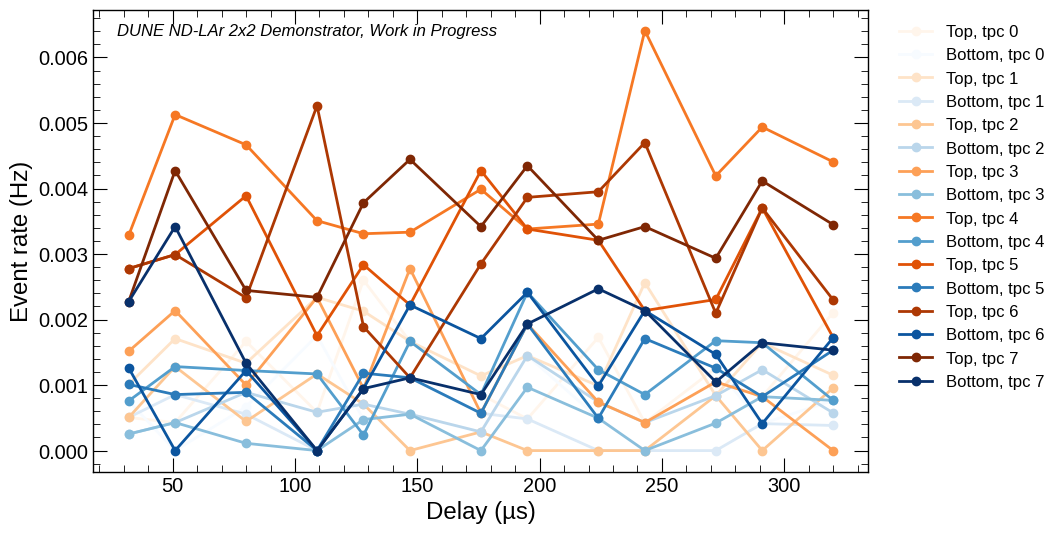

In [56]:
# probably need to normalize by the exposure or so
# how many files of each delay?
exposure = df[df["R"]=="R2"].groupby("delay")["file"].nunique()
# each file is 90 s, so we can calculate the total
exposure_time = exposure * 90
exposure_time

# make the same plot but with event count normalized by exposure time
fig, ax = plt.subplots(figsize=(10, 6))
for tpc in sorted(df["tpc"].unique()):
    subset_top = event_counts_grouped[event_counts_grouped.index.get_level_values("tpc") == tpc]["top"] / exposure_time
    subset_bottom = event_counts_grouped[event_counts_grouped.index.get_level_values("tpc") == tpc]["bottom"] / exposure_time
    plt.plot(subset_top.index.get_level_values("delay"), subset_top, marker="o", color=top_colors[tpc], label=f"Top, tpc {tpc}")
    plt.plot(subset_bottom.index.get_level_values("delay"), subset_bottom, marker="o", color=bottom_colors[tpc], label=f"Bottom, tpc {tpc}")
plt.xlabel("Delay (µs)")
plt.ylabel("Event rate (Hz)")
dune_label(ax)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

In [49]:
# let's now put all R1 to delay 0, and then add them to the delay plot (but normalize by total exposure time)
df_R1_to_delay = df.copy()
df_R1_to_delay.loc[df_R1_to_delay["R"]=="R1", "delay"] = 0

In [50]:
df_R1_to_delay

,file,event_id,delay,fprompt,tpc,det,energy,R,valid_event
60,/pscratch/sd/d/dunepro/mkramer/output/Reflow_2...,0,0,0.389976,4,5,77.672220,R1,21
188,/pscratch/sd/d/dunepro/mkramer/output/Reflow_2...,0,0,0.316151,6,3,103.445290,R1,17
237,/pscratch/sd/d/dunepro/mkramer/output/Reflow_2...,0,0,0.734850,5,15,337.417600,R1,33
272,/pscratch/sd/d/dunepro/mkramer/output/Reflow_2...,1,0,0.606478,1,12,55.644440,R1,101
329,/pscratch/sd/d/dunepro/mkramer/output/Reflow_2...,2,0,0.346780,7,15,81.103745,R1,212
...,...,...,...,...,...,...,...,...,...
150093,/pscratch/sd/d/dunepro/mkramer/output/Reflow_2...,3,0,0.616295,5,4,45.498684,R1,197
150099,/pscratch/sd/d/dunepro/mkramer/output/Reflow_2...,4,0,0.766225,5,14,33.789948,R1,209
150161,/pscratch/sd/d/dunepro/mkramer/output/Reflow_2...,0,176,0.834864,6,12,36.141320,R2,124
150191,/pscratch/sd/d/dunepro/mkramer/output/Reflow_2...,3,176,0.616295,5,4,45.498684,R2,197


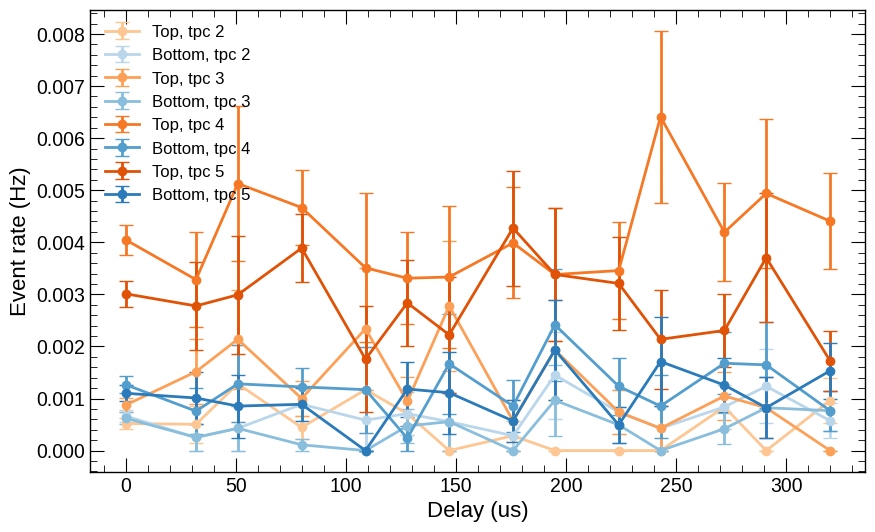

In [51]:
# how many files of each delay?
exposure = df_R1_to_delay.groupby("delay")["file"].nunique()
# each file is 90 s, so we can calculate the total
exposure_time = exposure * 90
exposure_time
event_counts = df_R1_to_delay.groupby(["delay", "tpc", "det"]).size().unstack(fill_value=0)
event_counts_grouped = event_counts.copy()
event_counts_grouped["top"] = event_counts[[4,5,6,7,12,13,14,15]].sum(axis=1)
event_counts_grouped["bottom"] = event_counts[[0,1,2,3,8,9,10,11]].sum(axis=1)

# make the same plot but with event count normalized by exposure time
plt.figure(figsize=(10, 6))
for tpc in [2,3,4,5]:#sorted(df["tpc"].unique()):
    subset_top = event_counts_grouped[event_counts_grouped.index.get_level_values("tpc") == tpc]["top"] / exposure_time
    subset_bottom = event_counts_grouped[event_counts_grouped.index.get_level_values("tpc") == tpc]["bottom"] / exposure_time
    # get uncertainties on the event counts using Poisson statistics
    std_top = np.sqrt(event_counts_grouped[event_counts_grouped.index.get_level_values("tpc") == tpc]["top"]) / exposure_time
    std_bottom = np.sqrt(event_counts_grouped[event_counts_grouped.index.get_level_values("tpc") == tpc]["bottom"]) / exposure_time

    plt.errorbar(subset_top.index.get_level_values("delay"), subset_top, std_top, capsize=5, marker="o", color=top_colors[tpc], label=f"Top, tpc {tpc}")
    plt.errorbar(subset_bottom.index.get_level_values("delay"), subset_bottom, std_bottom, capsize=5, marker="o", color=bottom_colors[tpc], label=f"Bottom, tpc {tpc}")
plt.xlabel("Delay (us)", fontsize=16)
plt.ylabel("Event rate (Hz)", fontsize=16)
plt.tick_params(axis='both', direction='in', labelsize=14)
plt.legend(fontsize=12)
plt.show()

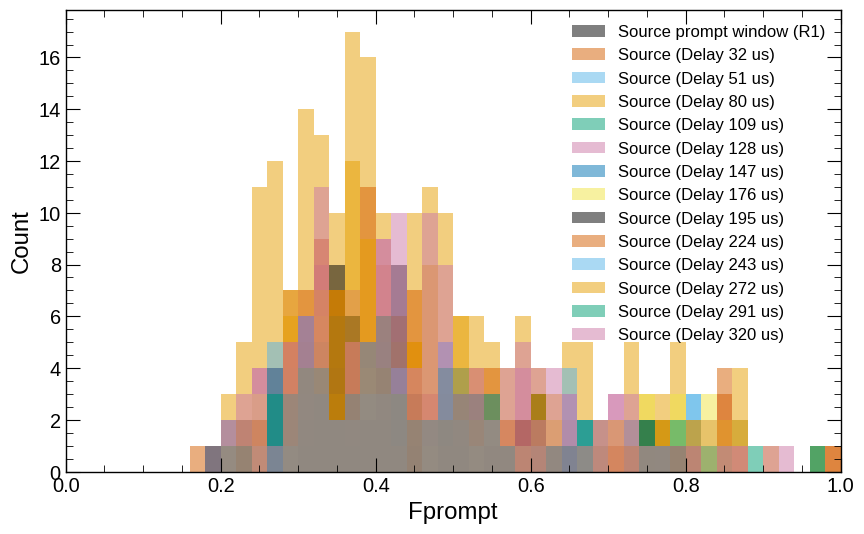

In [52]:
# Now let's look at the fprompt again
plt.figure(figsize=(10, 6))
for delay in sorted(df_R1_to_delay["delay"].unique()):
    subset = df_R1_to_delay[(df_R1_to_delay["delay"] == delay) & (df_R1_to_delay["R"] == "R2")]
    label = f"Source (Delay {delay} us)" if delay != 0 else "Source prompt window (R1)"
    plt.hist(subset["fprompt"], bins=bins, alpha=0.5, label=label)
plt.xlabel("Fprompt")
plt.ylabel("Count")
plt.xlim(0,1)
plt.legend()
plt.show()

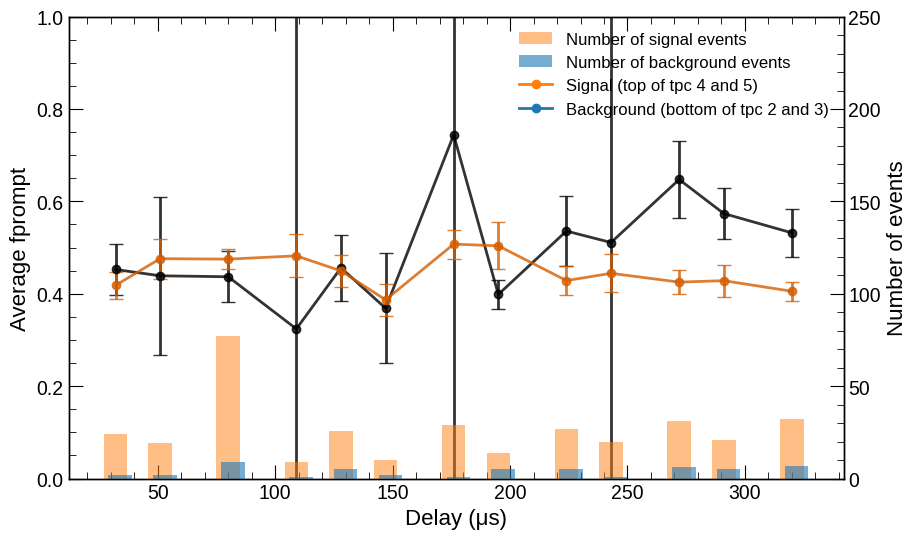

In [53]:
# define background as bottom of tpc 2 and 3
background = df[(df["R"] == "R2") & (df["tpc"].isin([2,3])) & (df["det"].isin([0,1,2,3,8,9,10,11]))]
# define signal as top of tpc 4 and 5
signal = df[(df["R"] == "R2") & (df["tpc"].isin([4,5])) & (df["det"].isin([4,5,6,7,12,13,14,15]))]
# per delay plot the average fprompt
average_fprompt_signal = signal.groupby("delay")["fprompt"].mean()
average_fprompt_background = background.groupby("delay")["fprompt"].mean()
# and the uncertainty on the average fprompt
std_fprompt_signal = signal.groupby("delay")["fprompt"].std()
std_fprompt_signal.fillna(1, inplace=True)
std_fprompt_background = background.groupby("delay")["fprompt"].std()
std_fprompt_background.fillna(1, inplace=True)
# but we need to take into account the number of events in the uncertainty, fewer events means more uncertainty on the average, so we can divide the std by the square root of the number of events
num_events_signal = signal.groupby("delay").size()
num_events_background = background.groupby("delay").size()
std_fprompt_signal = std_fprompt_signal / np.sqrt(num_events_signal)
std_fprompt_background = std_fprompt_background / np.sqrt(num_events_background)

plt.figure(figsize=(10, 6))

# get the number of events in each delay bin for signal and background
# num_events_signal = signal.groupby("delay").size()
# num_events_background = background.groupby("delay").size()
# and plot them on the same axis but with a different y-axis on the right


plt.errorbar(average_fprompt_background.index, average_fprompt_background, std_fprompt_background, capsize=5, marker="o", label="Background (bottom of tpc 2 and 3)", zorder=100, alpha=0.8)
plt.errorbar(average_fprompt_signal.index, average_fprompt_signal, std_fprompt_signal, capsize=5,marker="o", label="Signal (top of tpc 4 and 5)", zorder=100, alpha=0.8)
plt.ylim(0,1)
plt.ylabel("Average fprompt", fontsize=16)
plt.tick_params(axis='both', direction='in', labelsize=14)
plt.xlabel("Delay (μs)", fontsize=16)
ax2 = plt.gca().twinx()
ax2.bar(num_events_signal.index, num_events_signal, width=10, color="tab:orange", label="Number of signal events", alpha=0.5)
ax2.bar(num_events_background.index+2, num_events_background, width=10, color="tab:blue", label="Number of background events", alpha=0.6)
ax2.errorbar(np.nan, np.nan, marker="o", c="tab:orange", label = 'Signal (top of tpc 4 and 5)')
ax2.errorbar(np.nan, np.nan, marker="o", c="tab:blue", label = 'Background (bottom of tpc 2 and 3)')
plt.ylabel("Number of events", fontsize=16)
plt.xlabel("Delay (μs)", fontsize=16)
plt.tick_params(axis='both', direction='in', labelsize=14)
plt.ylim(0,250)
plt.legend(fontsize=12)
plt.show()



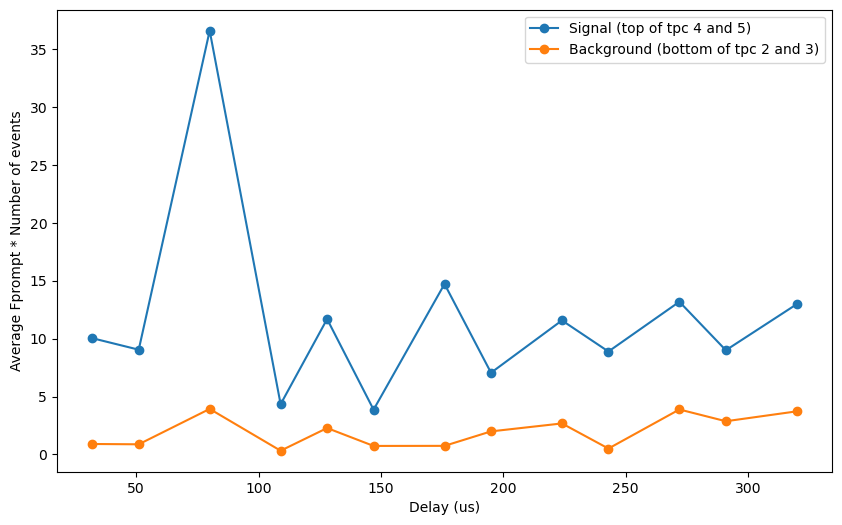

In [38]:
# plot average fprompt times number of events in each bine
plt.figure(figsize=(10, 6))
plt.plot(average_fprompt_signal.index, average_fprompt_signal * num_events_signal, marker="o", label="Signal (top of tpc 4 and 5)")
plt.plot(average_fprompt_background.index, average_fprompt_background * num_events_background, marker="o", label="Background (bottom of tpc 2 and 3)")
plt.ylabel("Average Fprompt * Number of events")
plt.xlabel("Delay (us)")
plt.legend()
plt.show()

In [39]:
# Read Edgar's csv
path = "/global/cfs/cdirs/dune/users/edgarmao/NeutronSim/Analysis/2x2_neutron_sources/AmBe/output/eps1_minsamples4/ambe_bin2_one_trig_32us_window_eps1size4.csv"
edgar_df = pd.read_csv(path)

# Background
bpath = '/global/cfs/cdirs/dune/users/edgarmao/NeutronSim/Analysis/2x2_neutron_sources/AmBe/output/eps1_minsamples4/nosource_ambe_bin2_one_trig_32us_window_eps1size4.csv'
b_df = pd.read_csv(bpath)

In [40]:
file_ids = {}
bfile_ids = {}
for num, file in enumerate(os.listdir("/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin2/one_trig_32us_window")):
    file_ids[num] = file

for num, file in enumerate(os.listdir("/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source")):
    bfile_ids[num] = file

In [47]:
# read a file, the find the events that match in Edgar's csv, and get the associated fprompt and energy
source_path = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin2/one_trig_32us_window/"
fprompts = []
energies = []
for file_id in file_ids:
    if file_id < 2:
        data = h5flow.data.H5FlowDataManager(source_path + file_ids[file_id], "r")
        try:
            matching = edgar_df[(edgar_df["cluster_label"] != -1) & (edgar_df["file_id"] == file_id)]
            # Group by light_id and filter once, outside the per-event loop
            grouped = matching.groupby("light_id").filter(lambda x: len(x) > 5)
            unique_ids = grouped["light_id"].unique()

            for id in unique_ids:
                fprompts.append(np.ma.filled(data['/light/events/', 'light/sum_hits'][int(id)]["fprompt"], -1))
                energies.append(np.ma.filled(data['/light/events/', 'light/sum_hits'][int(id)]["integral"], -1))
        finally:
            data.finish()  # always release the file handle

bsource_path = "/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin3/one_pmt_trig_no_source/"
bfprompts = []
benergies = []
for file_id in bfile_ids:
    if file_id < 2:
        data = h5flow.data.H5FlowDataManager(bsource_path + bfile_ids[file_id], "r")
        try:
            matching = edgar_df[(edgar_df["cluster_label"] != -1) & (edgar_df["file_id"] == file_id)]
            # Group by light_id and filter once, outside the per-event loop
            grouped = matching.groupby("light_id").filter(lambda x: len(x) > 5)
            unique_ids = grouped["light_id"].unique()

            for id in unique_ids:
                bfprompts.append(np.ma.filled(data['/light/events/', 'light/sum_hits'][int(id)]["fprompt"], -1))
                benergies.append(np.ma.filled(data['/light/events/', 'light/sum_hits'][int(id)]["integral"], -1))
        finally:
            data.finish()  # always release the file handle

IndexError: index 1870 is out of bounds for axis 0 with size 1662

In [46]:
file_id

0

In [138]:
# flatten the list into a list
fprompts = [item for sublist in fprompts for item in sublist]
energies = [item for sublist in energies for item in sublist]
# bfrompts = [item for sublist in bfprompts for item in sublist]


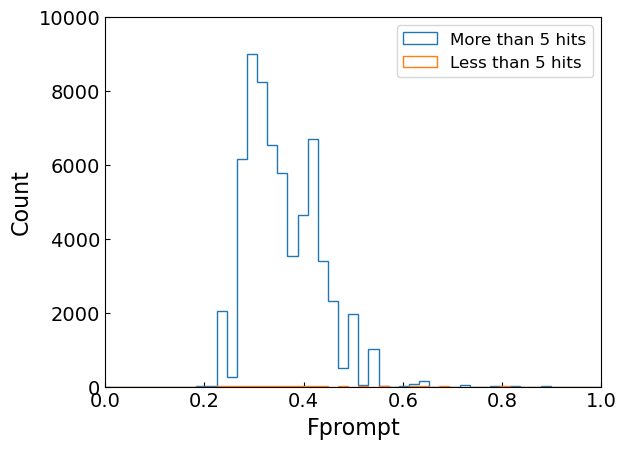

In [152]:
fprompts = np.array(fprompts)
bfprompts = np.array(bfprompts)
fprompts = fprompts[fprompts != -1]
bfprompts = bfprompts[bfprompts != -1]

bins = np.linspace(0, 1, 50)

plt.hist(fprompts, bins=bins, label="More than 5 hits", histtype="step", density=False)
plt.hist(fprompts_lessthan5, bins=bins, label="Less than 5 hits", histtype="step", density=False)

plt.xlim(0,1)
plt.ylim(0,10000)

plt.xlabel("Fprompt", fontsize=16)
plt.ylabel("Count", fontsize=16)
plt.tick_params(axis='both', direction='in', labelsize=14)
plt.legend(fontsize=12)
plt.show()

In [136]:
fprompts_lessthan5 = fprompts
background_lessthan5 = bfprompts

In [ ]:
# make a 2d histogram of fprompt vs energy for the events with more than 5 hits
plt.figure(figsize=(10, 6))
plt.hist2d(energies, fprompts, bins=50, range=[[0,1500], [0,1]], cmap="viridis", norm=LogNorm())
plt.ylim(0,1)
plt.xlabel("Waveform integral (PE)", fontsize=16)
plt.ylabel("Fprompt", fontsize=16)
plt.tick_params(axis='both', direction='in', labelsize=14)
plt.colorbar(label="Count", fontsize=16)
plt.show()

/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2/flow/source_ambe_bin2/one_trig_32us_window/mpd_run_run2data_rctl_615_p45_v0p2.FLOW.hdf5
data['light/events', 'light/wvfm']['samples'][1022][0, 4, :, :]

In [46]:
wvfms = data['light/events', 'light/wvfm']['samples'][int(id)]

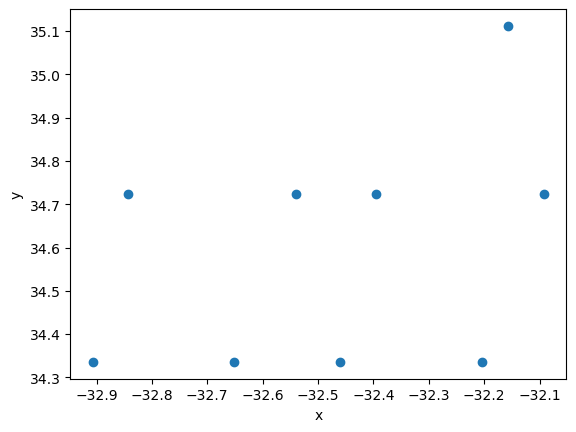

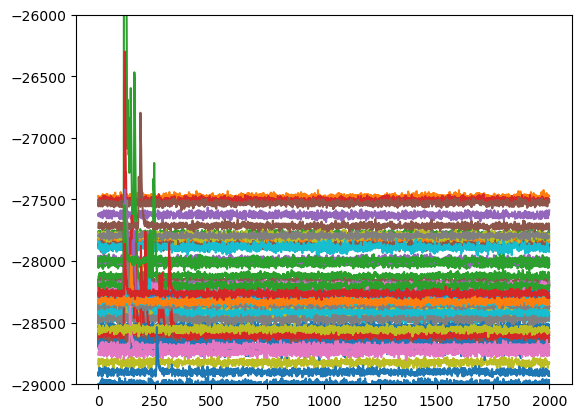

In [49]:
plt.scatter(event["x"], event["y"])
plt.xlabel("x")
plt.ylabel("y")
plt.show()

for i in range(64):
    plt.plot(wvfms[0, 4, i, :])
plt.ylim(-29000,-26000)
plt.show()